 Wine Quality Prediction using Logistic Regression

##  Objective
To classify whether a wine is **Good** or **Bad** based on its chemical properties using Logistic Regression.

##  Approach
Since Logistic Regression is a classification algorithm:
- Good Wine → quality ≥ 7 → 1
- Bad Wine → quality < 7 → 0
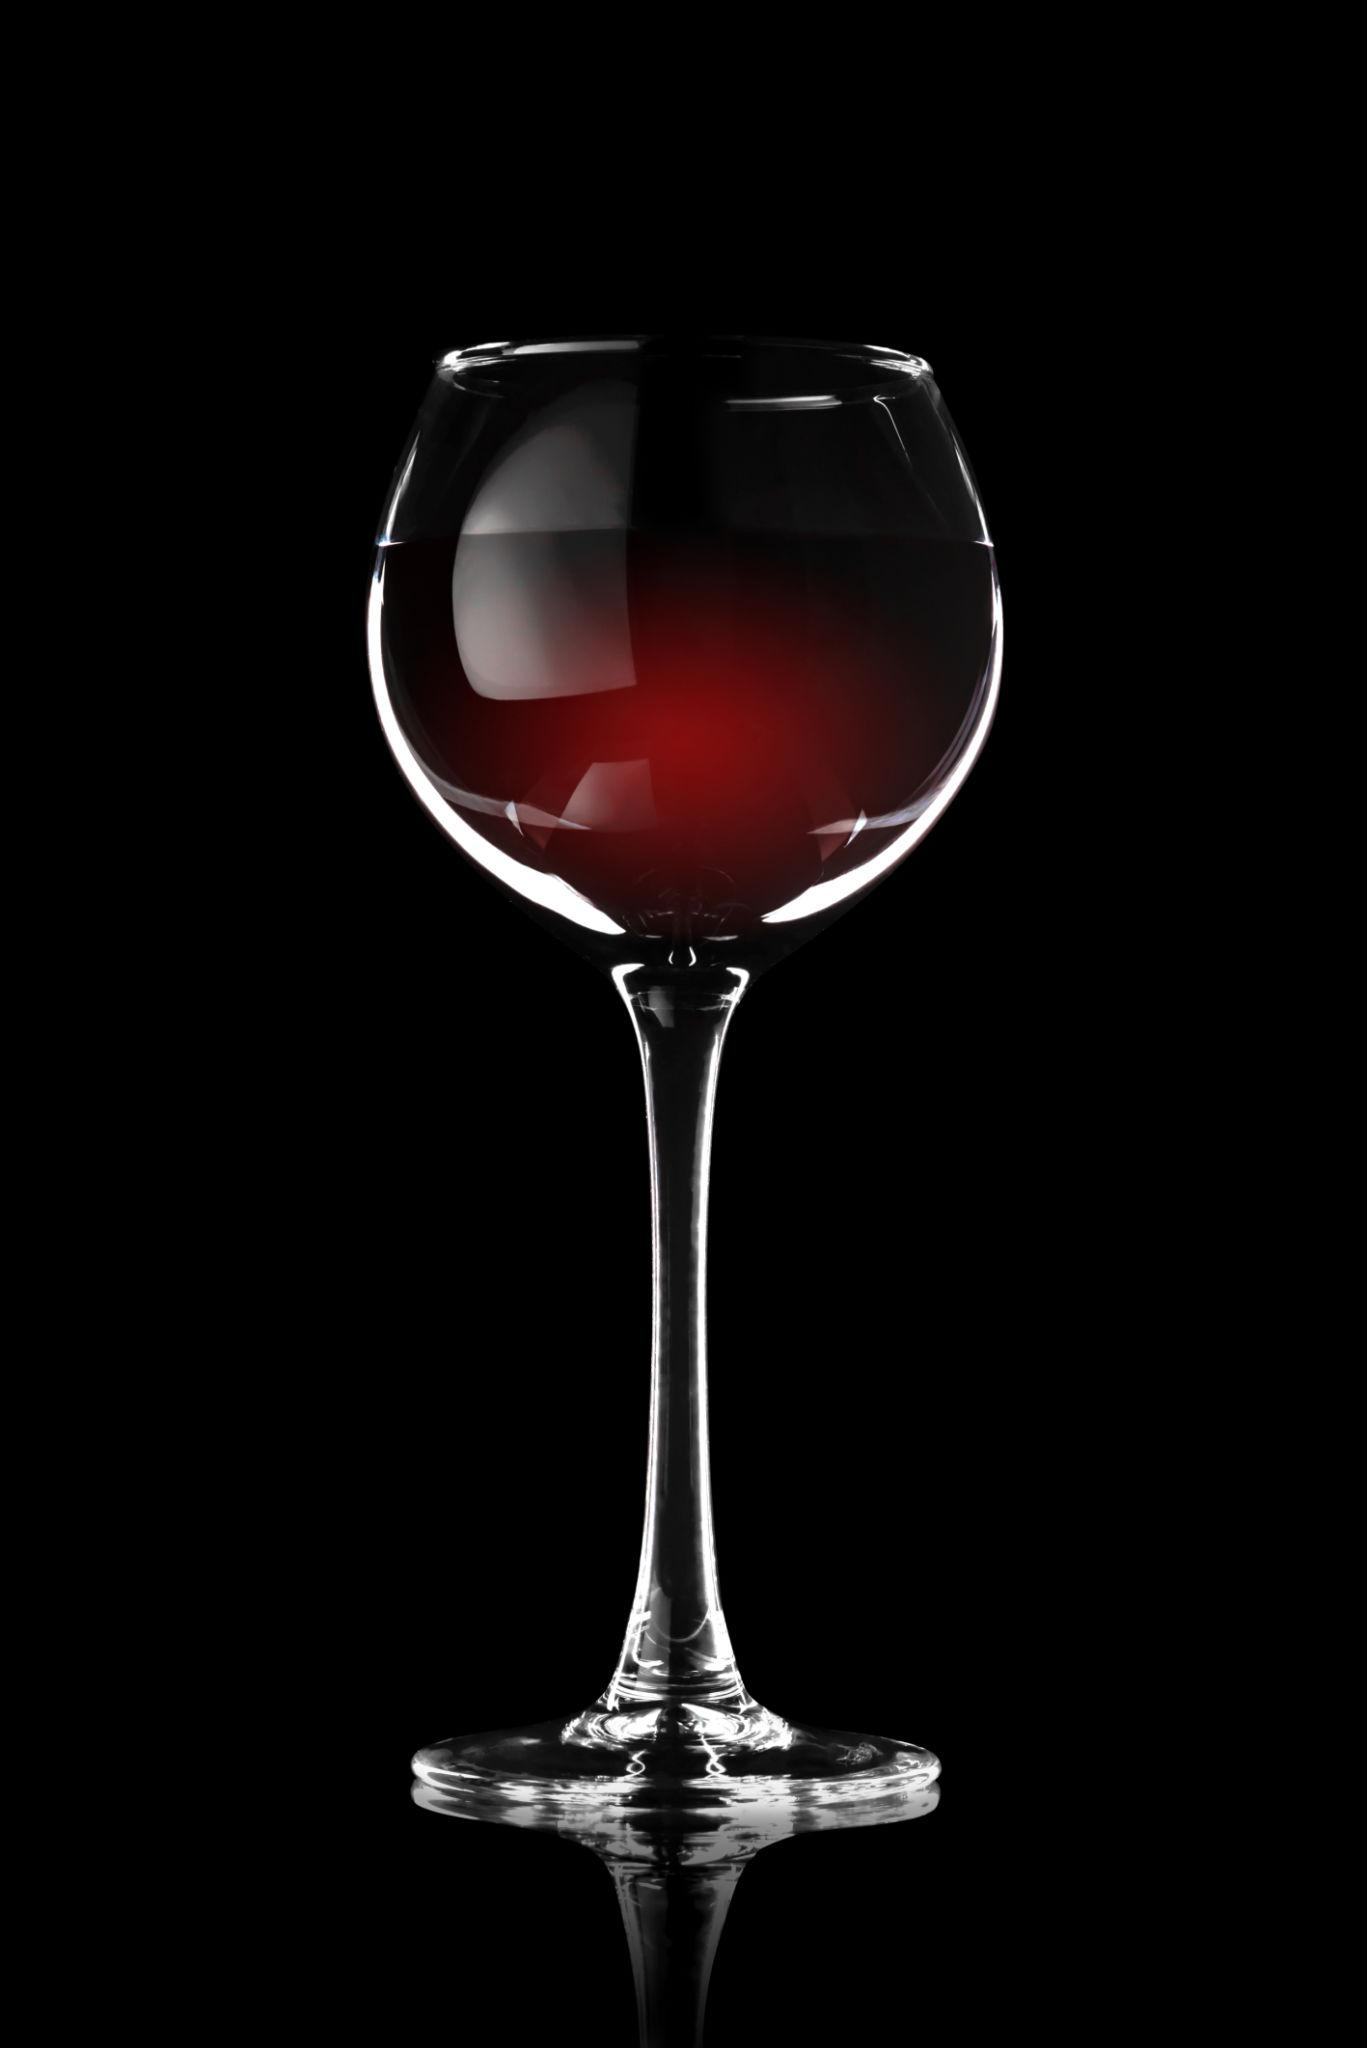

## Import Libraries

We import libraries for:
- Data handling
- Visualization
- Machine Learning

In [ ]:
#  IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Optional (for improvement)
from sklearn.preprocessing import StandardScaler

##  Load Dataset

Load the dataset using pandas and display first few rows.
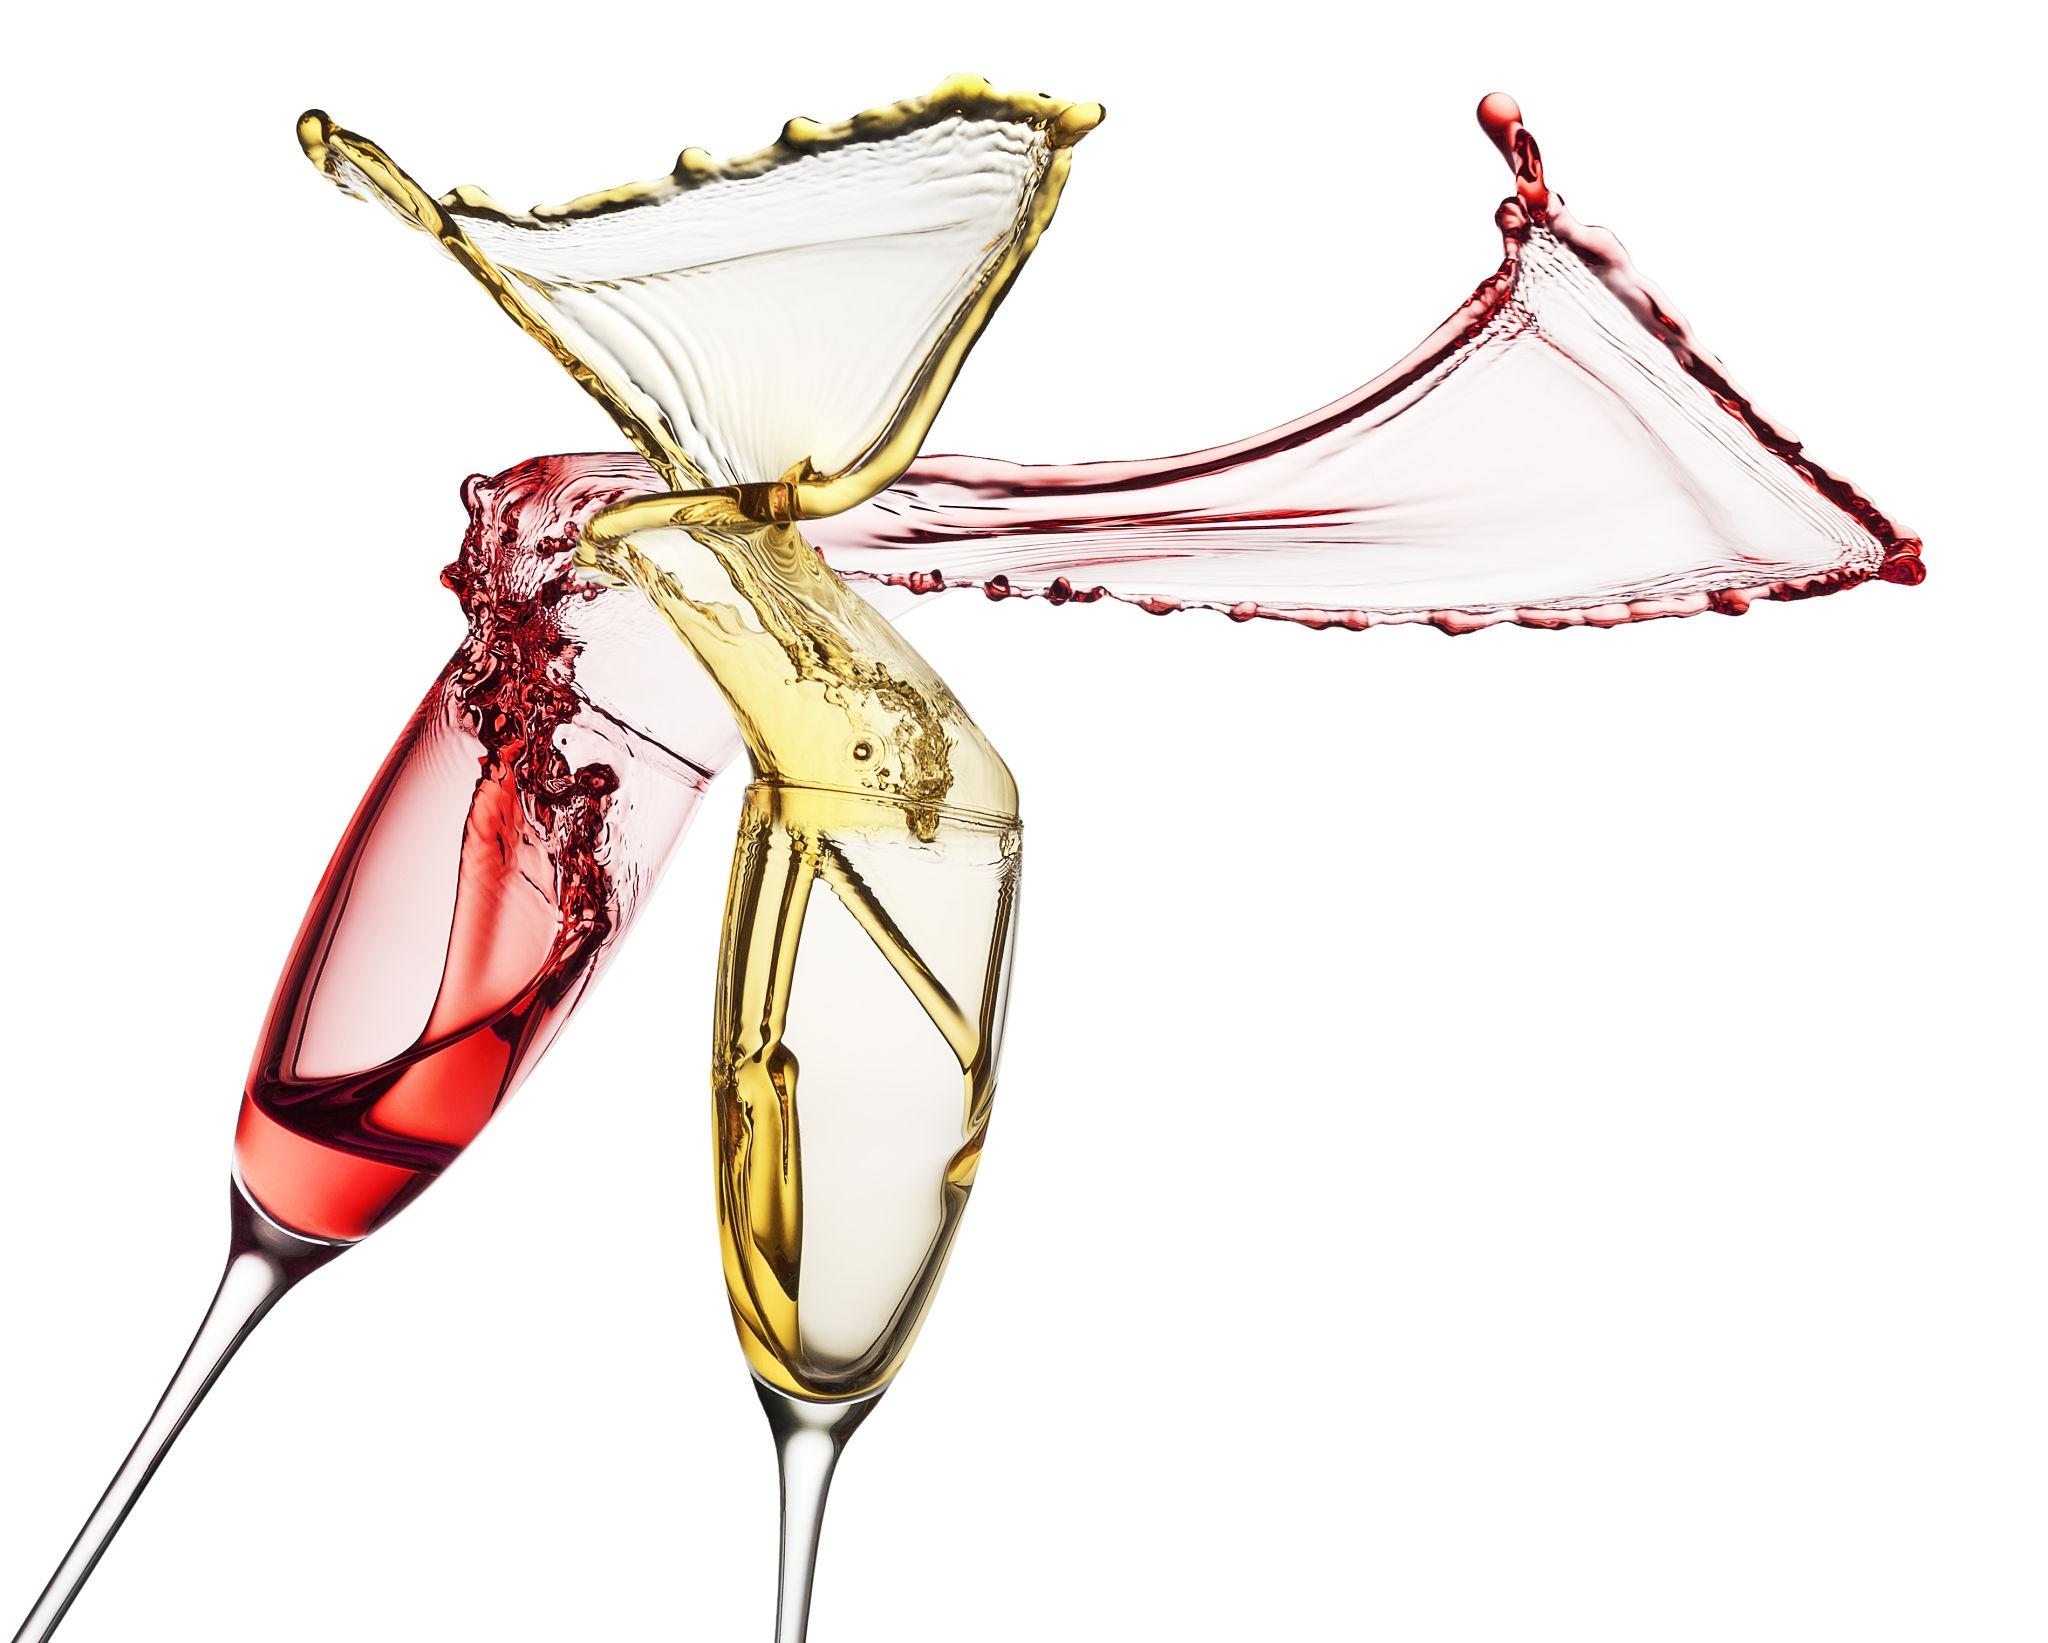

In [ ]:

#  LOAD DATASET

df = pd.read_csv('/content/winequality-red.csv')

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


##  Data Understanding

Check:
- Structure
- Statistics
- Missing values

In [ ]:
#  DATA UNDERSTANDING

print("Dataset Info:\n")
print(df.info())

print("\nStatistical Summary:\n")
print(df.describe())

print("\nMissing Values:\n")
print(df.isnull().sum())

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
None

Statistical Summary:

       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    159

## Target Conversion

Convert quality into binary classification:
- 1 → Good Wine (≥7)
- 0 → Bad Wine (<7)
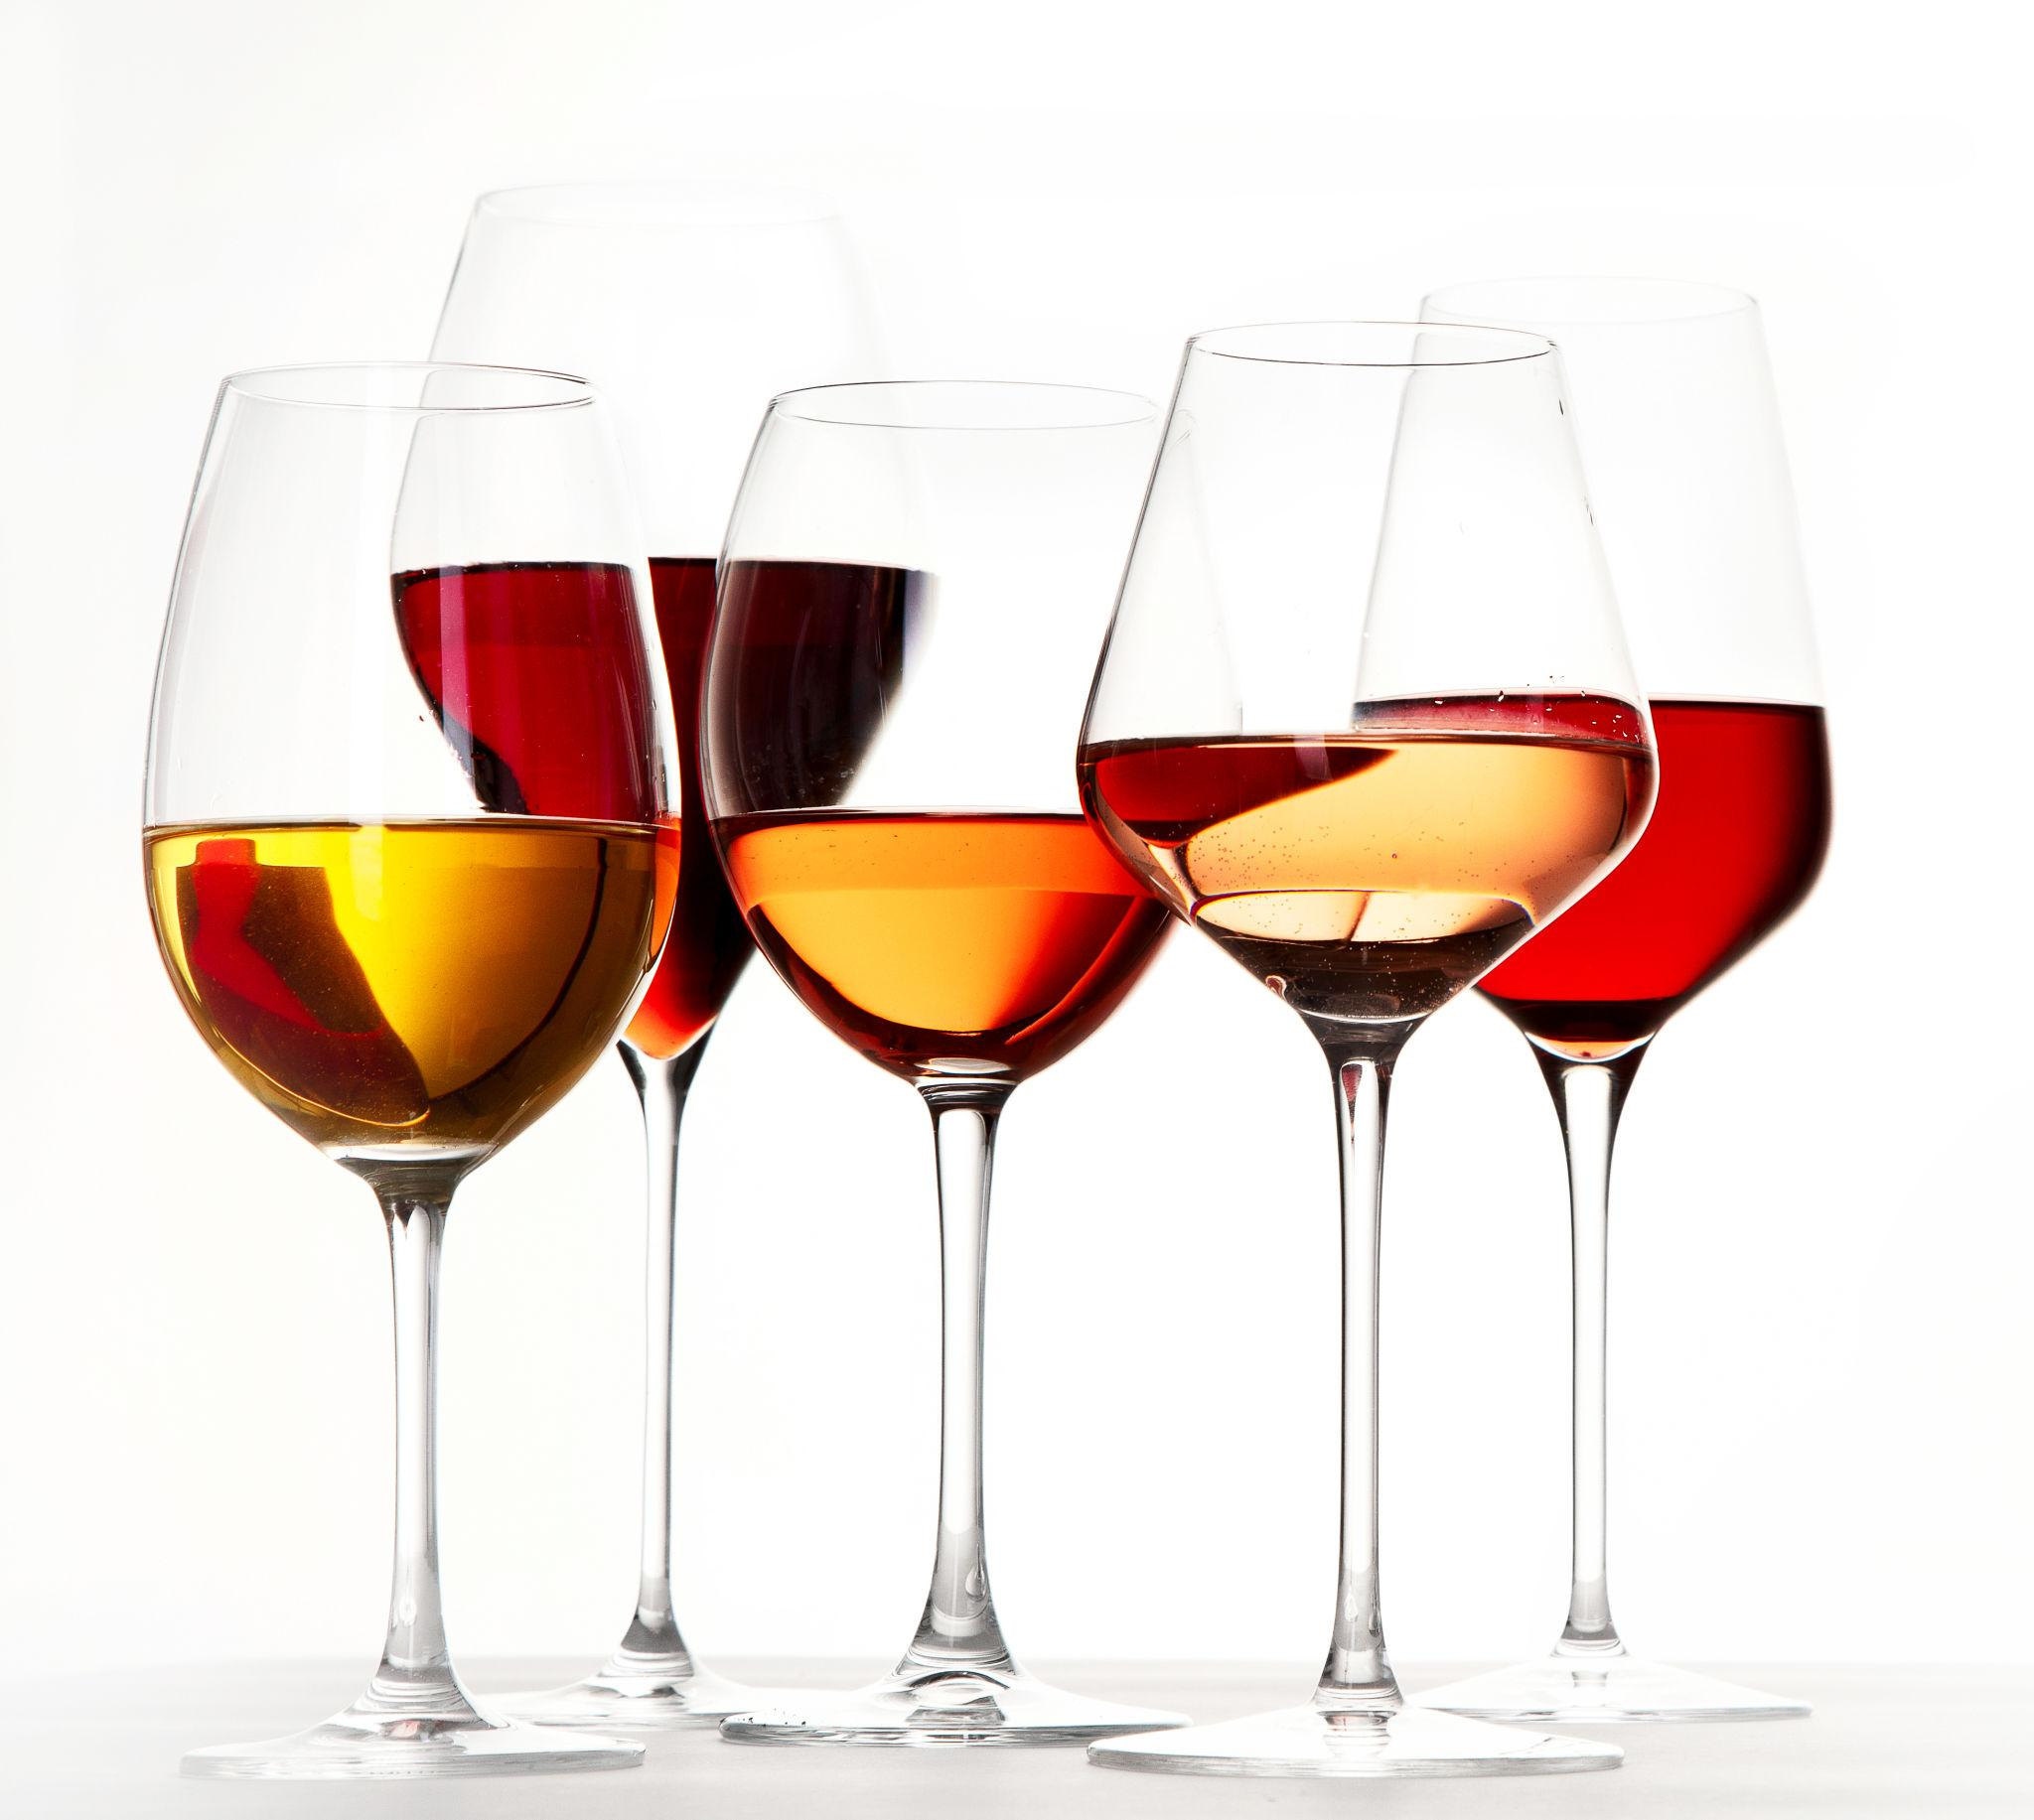

In [ ]:
# 🎯 TARGET CONVERSION

df['quality'] = df['quality'].apply(lambda x: 1 if x >= 7 else 0)

print(df['quality'].value_counts())

quality
0    1382
1     217
Name: count, dtype: int64


## 📊 Data Visualization

- Distribution of target
- Feature correlation


Dataset Loaded Successfully!

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8 

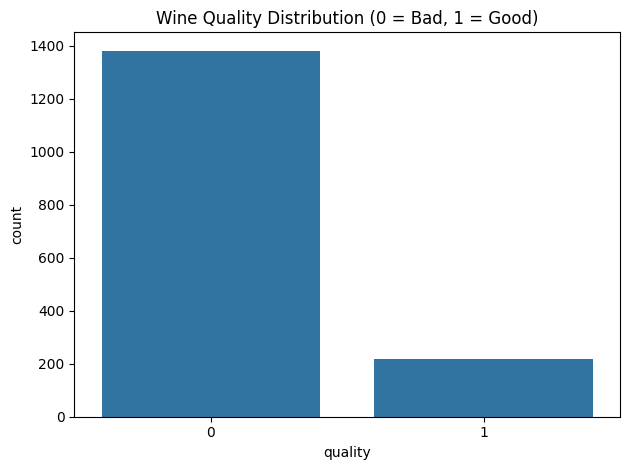


--------------------------------------------------------------------------------
This Count Plot shows how many wines are labeled Bad (0) and Good (1).
It helps us understand whether the dataset is balanced or imbalanced between the
two classes.
A large gap between bars means the model may be biased towards the majority
class.
--------------------------------------------------------------------------------


  Correlation Heatmap



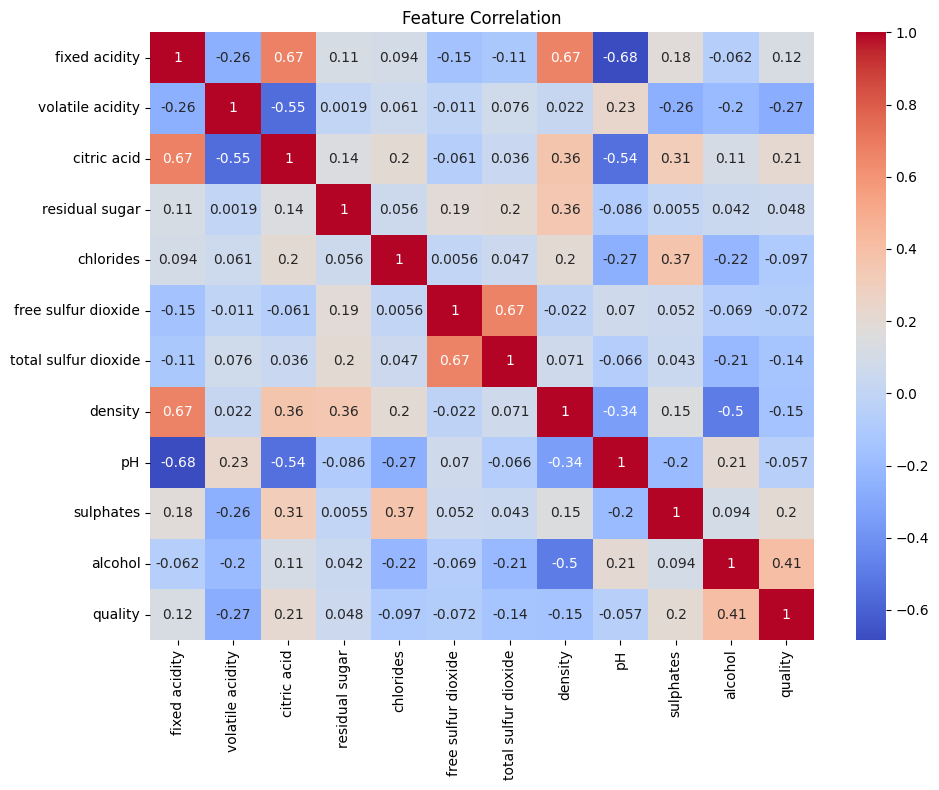


--------------------------------------------------------------------------------
This Heatmap displays the Pearson correlation between every pair of features.
Values close to +1 = strong positive relationship | Values close to -1 = strong
negative relationship | Near 0 = no linear relationship.
Use this to spot which features are most strongly correlated with wine quality
(last row/column).
--------------------------------------------------------------------------------


  Feature Distributions



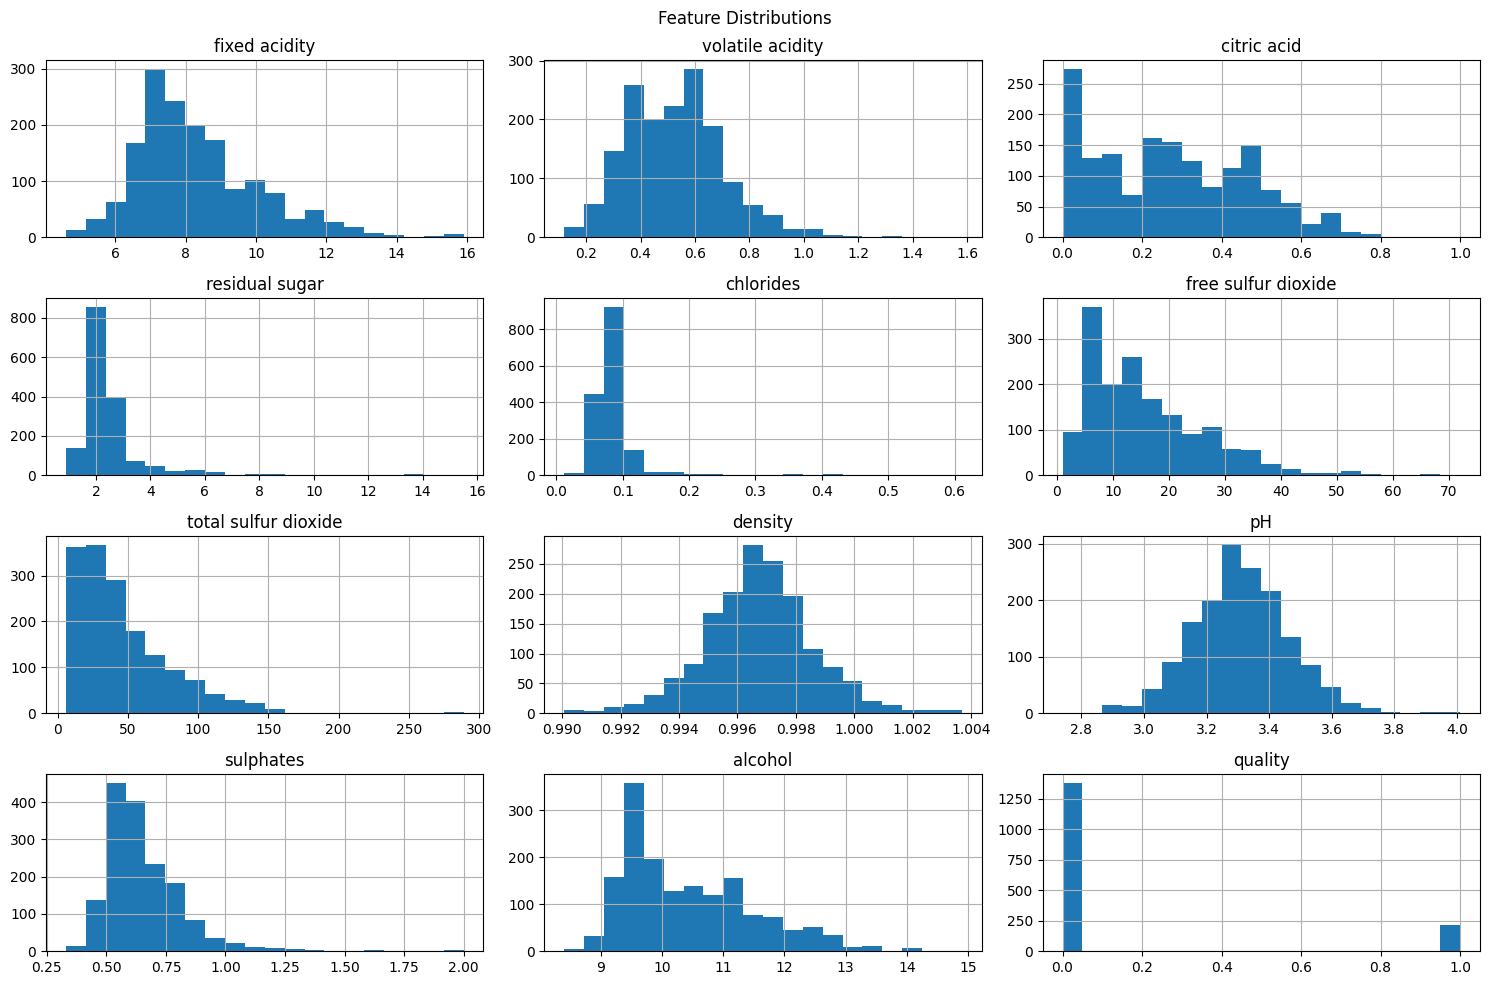


--------------------------------------------------------------------------------
These Histograms show how values of each individual feature are distributed
across the dataset.
A bell-shaped curve suggests normal distribution. Skewed bars indicate outliers
or uneven spread.
Both skewness and outliers can affect model performance and may require
preprocessing.
--------------------------------------------------------------------------------


  Boxplots



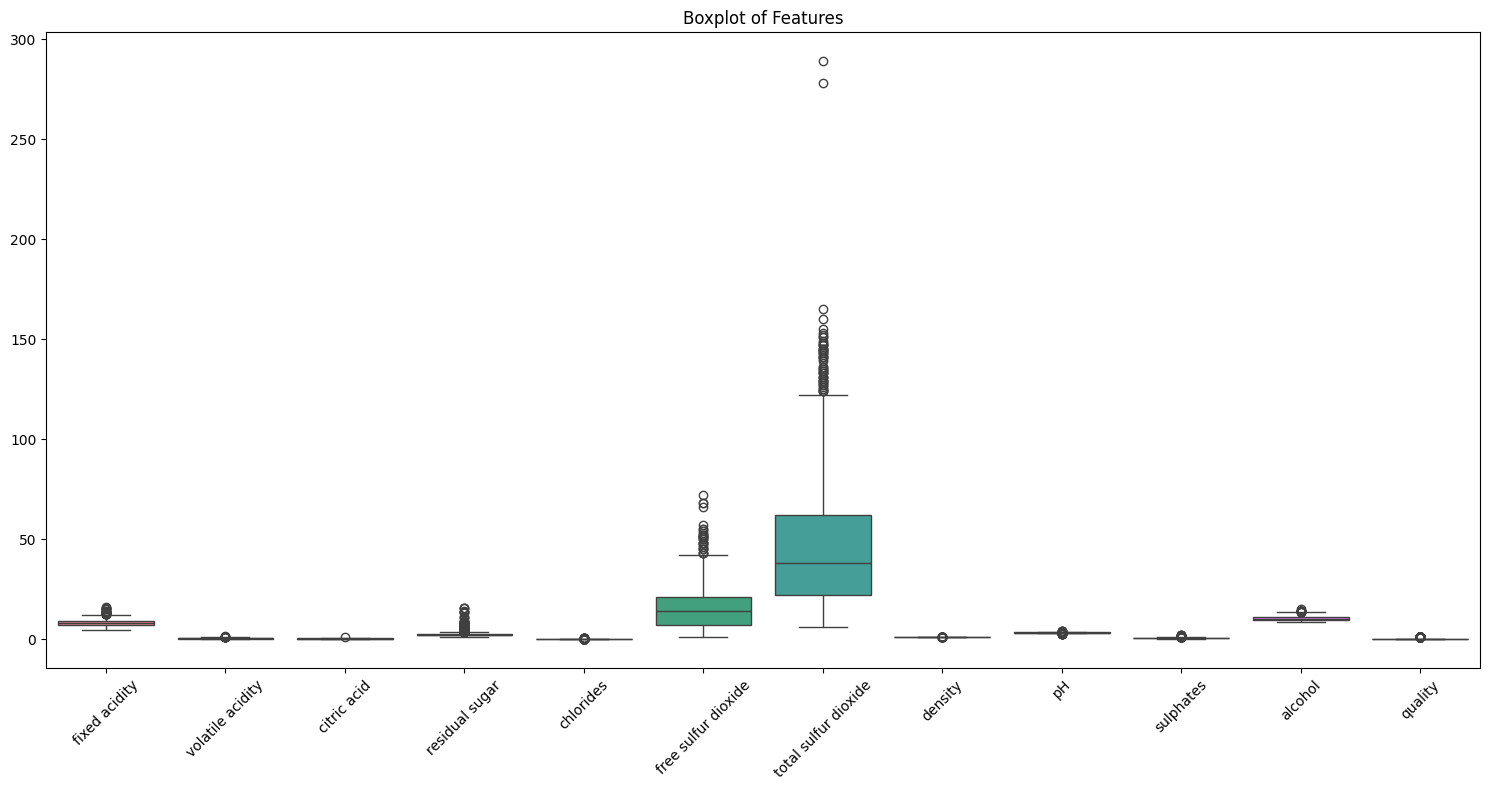


--------------------------------------------------------------------------------
These Boxplots display the median, spread (IQR), and outliers for each feature.
The box = middle 50% of data | Line inside box = median | Dots beyond the
whiskers = outliers.
Features with many outlier dots may need treatment before being fed into the
model.
--------------------------------------------------------------------------------


  Model Training

Model trained successfully!

  Predictions


  Confusion Matrix



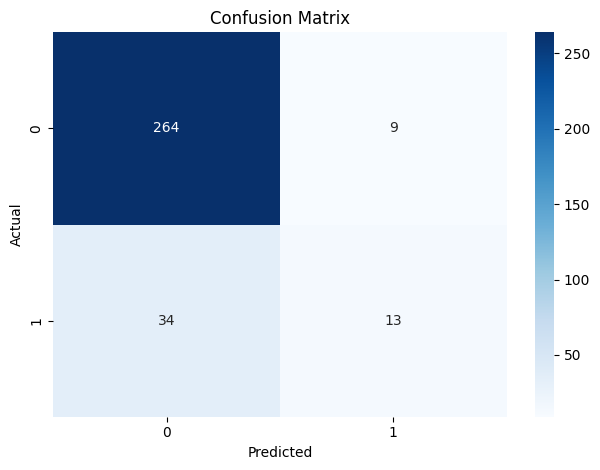


--------------------------------------------------------------------------------
This Confusion Matrix shows 4 prediction outcomes of the model.
True Positive = correctly predicted Good | True Negative = correctly predicted
Bad.
False Positive = Bad wine wrongly called Good | False Negative = Good wine
wrongly called Bad.
Higher values on the diagonal (top-left to bottom-right) = better model
performance.
--------------------------------------------------------------------------------


  Classification Report

              precision    recall  f1-score   support

           0       0.89      0.97      0.92       273
           1       0.59      0.28      0.38        47

    accuracy                           0.87       320
   macro avg       0.74      0.62      0.65       320
weighted avg       0.84      0.87      0.84       320


  ROC Curve



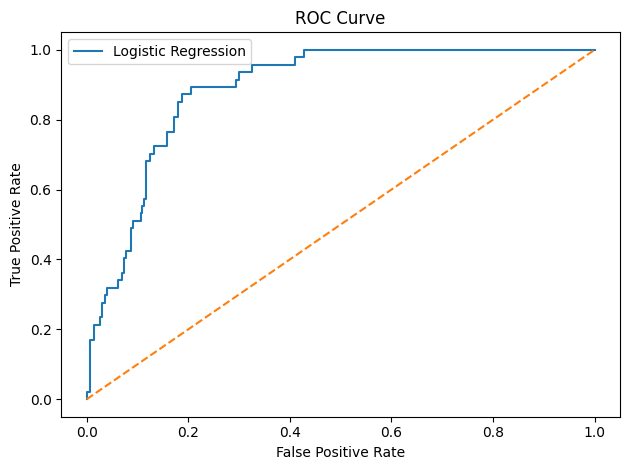


--------------------------------------------------------------------------------
This ROC Curve plots True Positive Rate vs False Positive Rate at every possible
decision threshold.
The closer the curve hugs the top-left corner, the better the model is at
distinguishing Good from Bad wine.
The dashed diagonal line = random guess baseline. A curve above it = model is
better than random.
--------------------------------------------------------------------------------

AUC Score: 0.8873821214246747

  Precision-Recall Curve



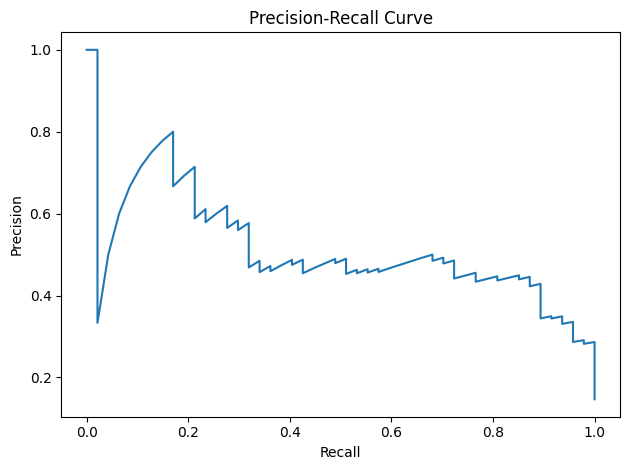


--------------------------------------------------------------------------------
This Precision-Recall Curve is especially useful when the dataset is imbalanced.
Precision = of all wines predicted Good, how many actually were Good.
Recall = of all actual Good wines, how many did the model successfully catch.
A curve that stays high on both axes indicates a strong and reliable model.
--------------------------------------------------------------------------------


  Threshold vs Accuracy



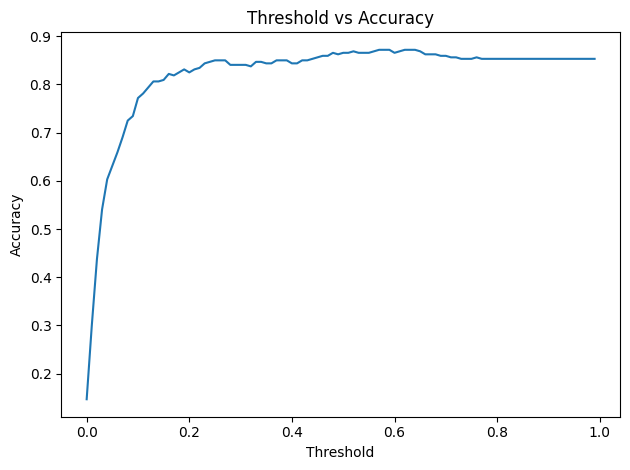


--------------------------------------------------------------------------------
This Line Plot shows how overall accuracy changes as the decision threshold
shifts from 0 to 1.
By default the model uses 0.5 as the cutoff to decide Good vs Bad wine.
The peak of this curve shows the optimal threshold that gives the highest
accuracy for this dataset.
--------------------------------------------------------------------------------


  Feature Importance



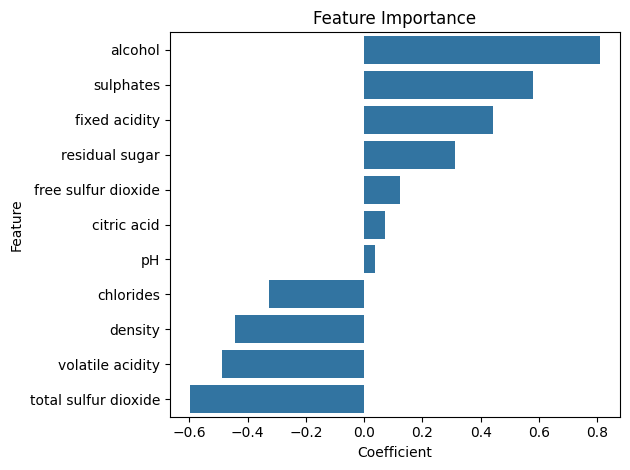


--------------------------------------------------------------------------------
This Bar Plot ranks each feature by its Logistic Regression coefficient value.
Large positive value = that feature strongly pushes the prediction towards Good
wine.
Large negative value = that feature strongly pushes the prediction towards Bad
wine.
Features near zero have very little influence on the model's final decision.
--------------------------------------------------------------------------------


  Feature vs Target Distribution



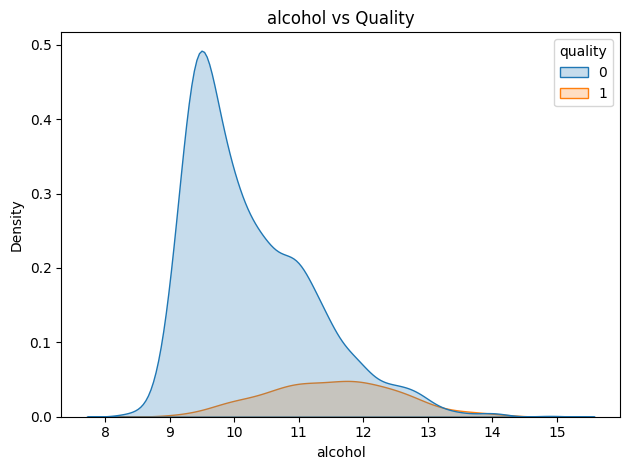


--------------------------------------------------------------------------------
This KDE Plot shows the probability distribution of 'alcohol' for Bad (0) and
Good (1) wines.
Where the two curves are far apart, 'alcohol' is a strong separator between the
two classes.
Where the curves heavily overlap, 'alcohol' alone is not enough to distinguish
wine quality.
--------------------------------------------------------------------------------



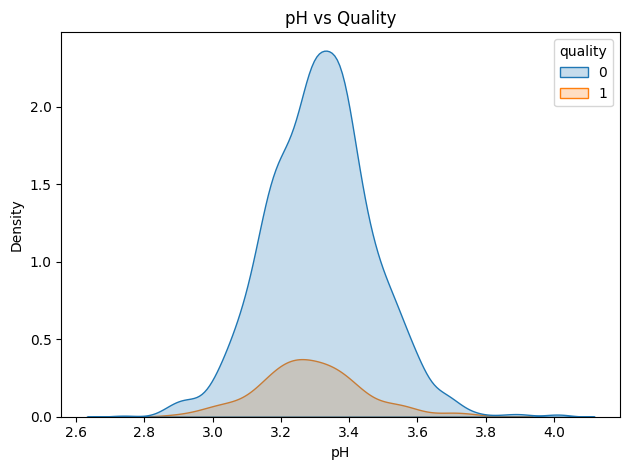


--------------------------------------------------------------------------------
This KDE Plot shows the probability distribution of 'pH' for Bad (0) and Good
(1) wines.
Where the two curves are far apart, 'pH' is a strong separator between the two
classes.
Where the curves heavily overlap, 'pH' alone is not enough to distinguish wine
quality.
--------------------------------------------------------------------------------



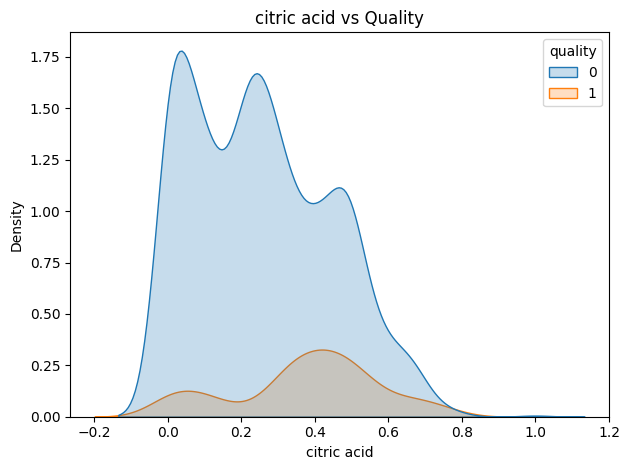


--------------------------------------------------------------------------------
This KDE Plot shows the probability distribution of 'citric acid' for Bad (0)
and Good (1) wines.
Where the two curves are far apart, 'citric acid' is a strong separator between
the two classes.
Where the curves heavily overlap, 'citric acid' alone is not enough to
distinguish wine quality.
--------------------------------------------------------------------------------


  Pairplot



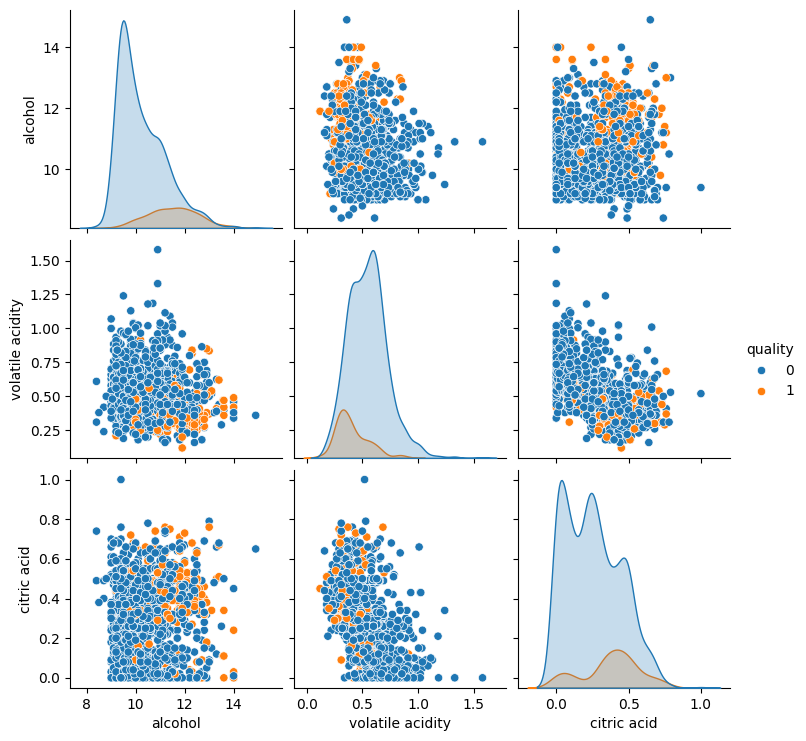


--------------------------------------------------------------------------------
This Pairplot Matrix shows every combination of scatter plots between the
selected features.
Each dot is colored by wine quality class. Diagonal plots show individual
feature distributions.
Clusters clearly separated by color = those two features together are strong
predictors of wine quality.
--------------------------------------------------------------------------------


  Sigmoid Function



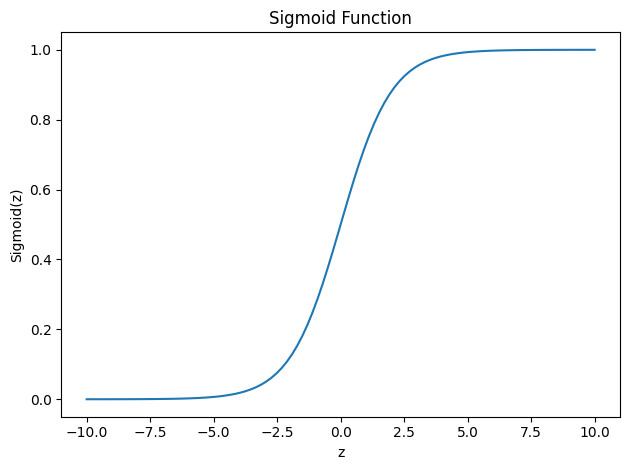


--------------------------------------------------------------------------------
This curve shows the Sigmoid (Logistic) Function — the mathematical backbone of
Logistic Regression.
It converts any raw numeric input (z) into a probability value between 0 and 1.
Output above 0.5 = model predicts Good wine (1) | Output below 0.5 = model
predicts Bad wine (0).
--------------------------------------------------------------------------------


  Train-Test Accuracy Comparison



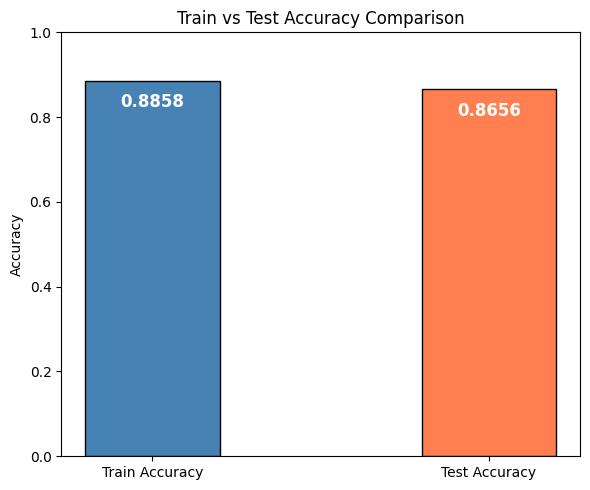


--------------------------------------------------------------------------------
This Bar Chart compares model accuracy on training data vs completely unseen
test data.
Train Accuracy much higher than Test Accuracy = overfitting (model memorized
instead of learning).
Both similarly low = underfitting. Ideally both bars should be high and close to
each other.
--------------------------------------------------------------------------------

Train Accuracy: 0.8858  |  Test Accuracy: 0.8656

  Cross Validation



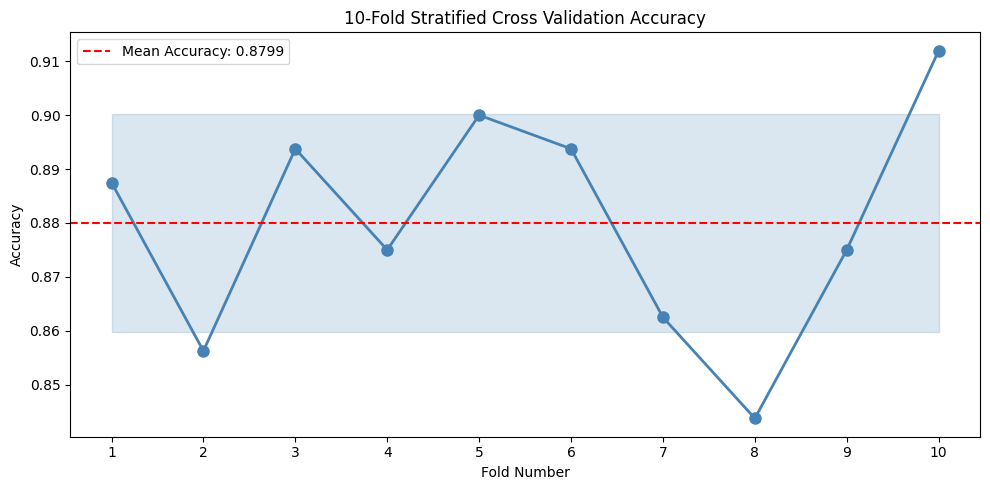


--------------------------------------------------------------------------------
This Line Plot shows the model's accuracy across 10 different train-test splits
of the entire dataset.
Each point = accuracy for one fold | Red dashed line = mean accuracy | Shaded
band = standard deviation.
A stable flat line with small fluctuations = model generalizes consistently and
is not dependent on one lucky split.
--------------------------------------------------------------------------------

CV Scores: [0.8875     0.85625    0.89375    0.875      0.9        0.89375
 0.8625     0.84375    0.875      0.91194969]
Mean CV Accuracy: 0.8799  |  Std Dev: 0.0202

  Hyperparameter Tuning



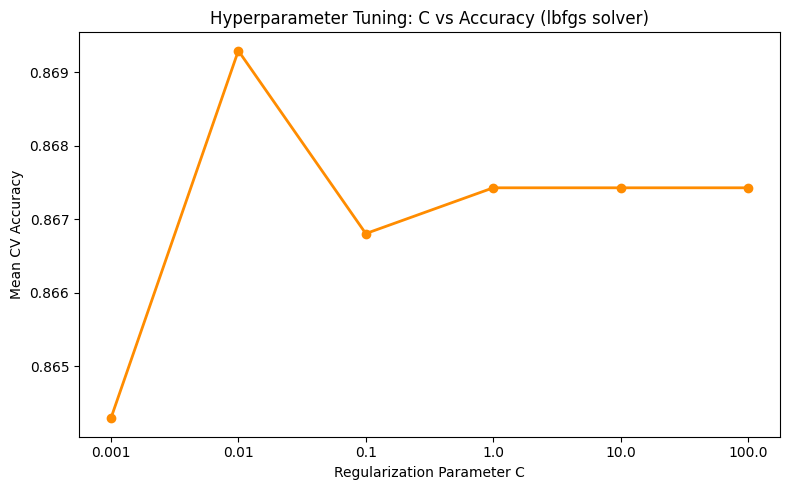


--------------------------------------------------------------------------------
This Line Plot shows how model accuracy changes as regularization parameter C is
varied.
Small C = strong regularization (simpler model, may underfit) | Large C = weak
regularization (may overfit).
The peak of the curve is the best value of C — giving the highest accuracy
without overfitting.
--------------------------------------------------------------------------------

Best Parameters : {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV Accuracy: 0.8693

  Decision Boundary Visualization



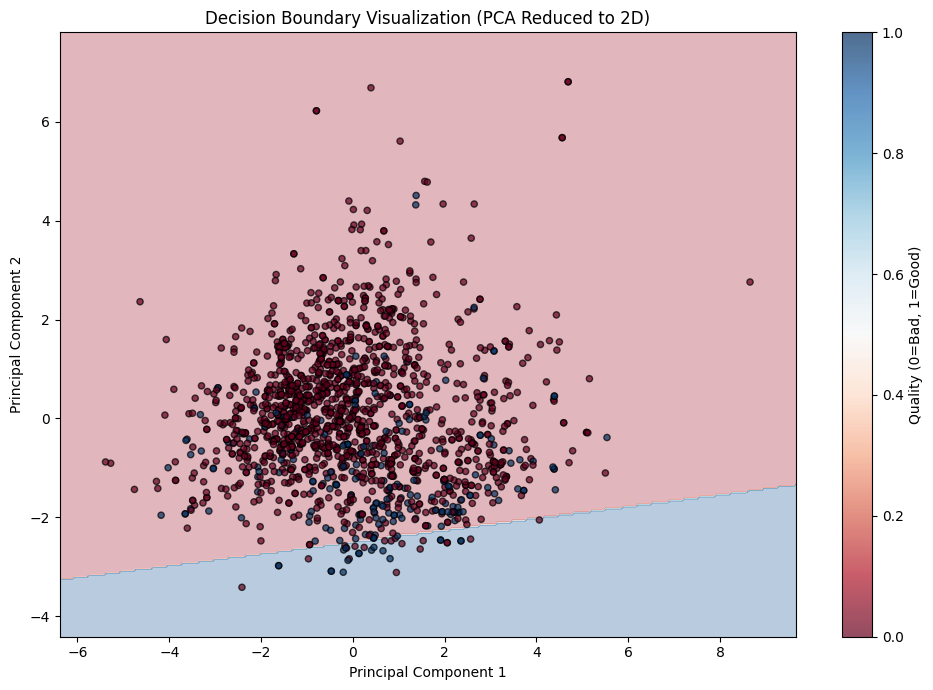


--------------------------------------------------------------------------------
This plot shows WHERE the model draws its decision line to separate Good wines
from Bad wines.
PCA compressed all 11 features into 2 dimensions so the boundary can be
visualized on a 2D plane.
Each dot = one wine sample | Background color = model's predicted class for that
region.
Dots sitting on the wrong background color = misclassified samples.
--------------------------------------------------------------------------------


  Precision-Recall-F1 Bar Graph



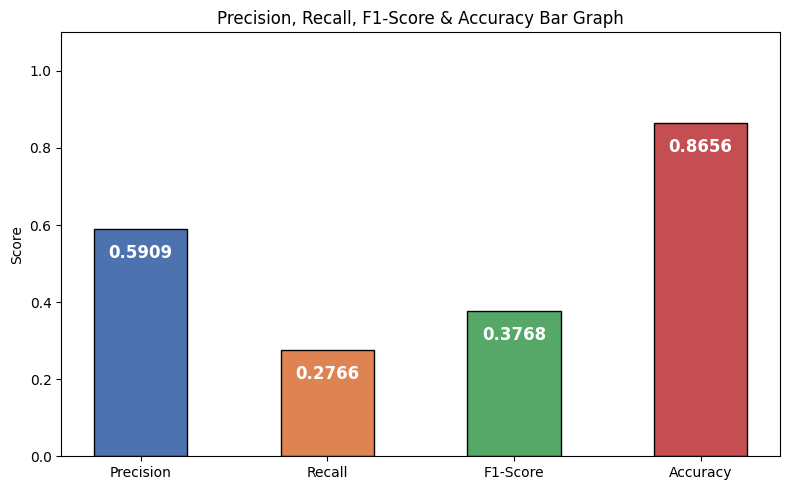


--------------------------------------------------------------------------------
This Bar Chart shows all four key classification metrics side by side in one
single view.
Precision = of all predicted Good wines, how many were actually Good.
Recall = of all actual Good wines, how many did the model catch.
F1-Score = harmonic balance between Precision and Recall | Accuracy = total
correct out of all predictions.
--------------------------------------------------------------------------------

Precision: 0.5909  |  Recall: 0.2766  |  F1-Score: 0.3768  |  Accuracy: 0.8656

  Feature Selection



/tmp/ipykernel_12309/2517988057.py:542: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Score', y='Feature', data=feature_scores, palette='viridis')


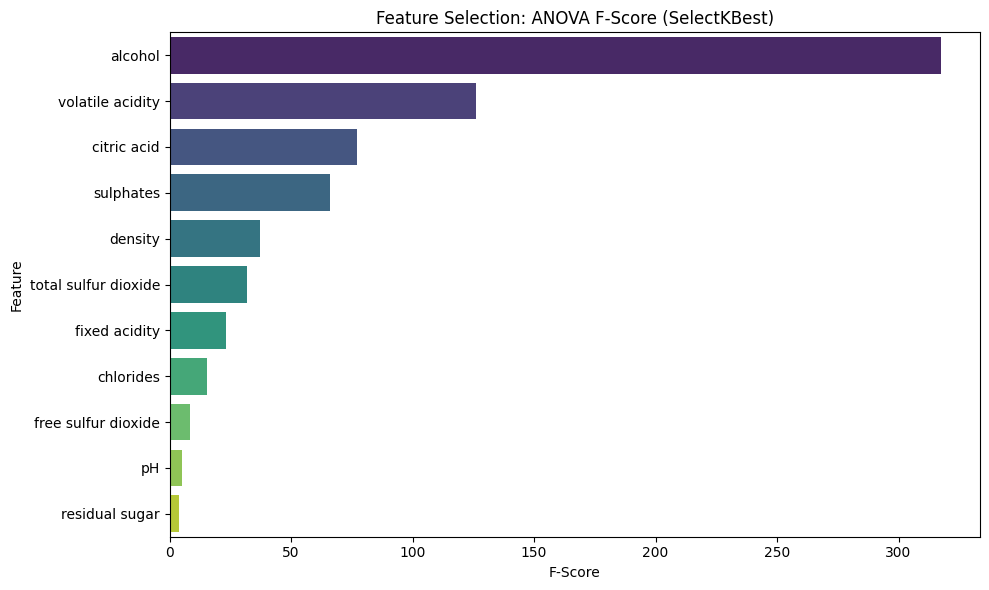


--------------------------------------------------------------------------------
This Bar Chart ranks every feature using the ANOVA F-Score statistical method.
A higher F-Score means that feature's values differ significantly between Good
and Bad wine classes.
Features at the top are statistically most useful for prediction. Features at
the bottom contribute very little.
--------------------------------------------------------------------------------

             Feature      Score
             alcohol 317.650903
    volatile acidity 126.290916
         citric acid  77.184567
           sulphates  66.185378
             density  36.990465
total sulfur dioxide  31.702481
       fixed acidity  23.356885
           chlorides  15.266188
 free sulfur dioxide   8.263373
                  pH   5.257619
      residual sugar   3.654017

RFE Feature Ranking:

             Feature  Selected  Ranking
       fixed acidity      True        1
    volatile acidity      True        1
total sulfur dio

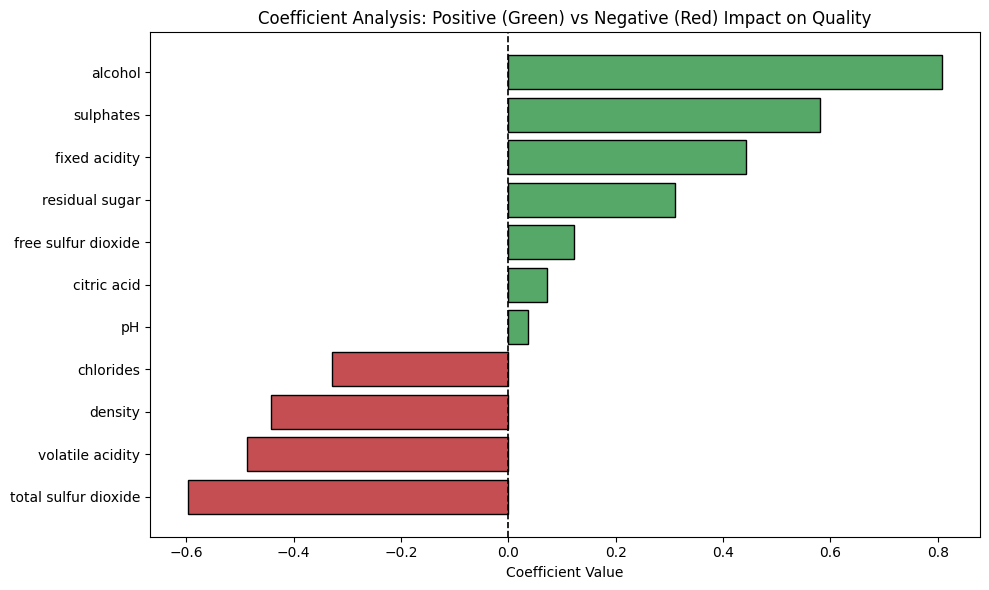


--------------------------------------------------------------------------------
This Horizontal Bar Chart shows exactly how each feature pushes the model's
prediction.
Green bars (positive) = higher values of that feature push prediction towards
Good wine.
Red bars (negative) = higher values of that feature push prediction towards Bad
wine.
The longer the bar in either direction, the stronger that feature's influence on
the model.
--------------------------------------------------------------------------------

             Feature  Coefficient  Abs_Coef
             alcohol     0.808446  0.808446
total sulfur dioxide    -0.597413  0.597413
           sulphates     0.580207  0.580207
    volatile acidity    -0.487503  0.487503
             density    -0.442451  0.442451
       fixed acidity     0.442259  0.442259
           chlorides    -0.327903  0.327903
      residual sugar     0.310809  0.310809
 free sulfur dioxide     0.122823  0.122823
         citric acid     0.071551  0.0715

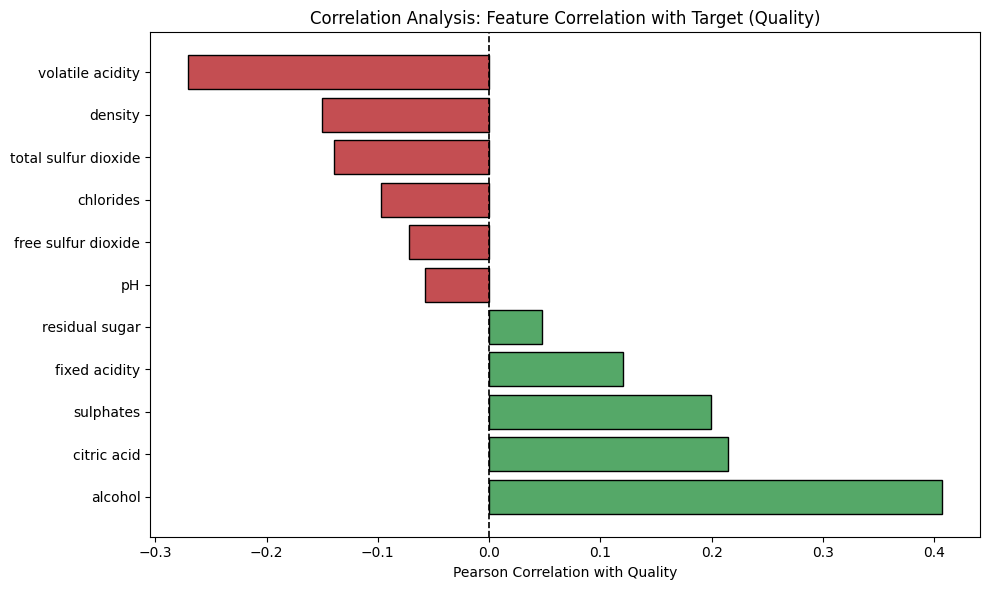


--------------------------------------------------------------------------------
This Horizontal Bar Chart shows the direct linear relationship between each
feature and wine quality.
Green bars = that feature tends to increase as wine quality increases (positive
correlation).
Red bars = that feature tends to decrease as wine quality increases (negative
correlation).
Longer bars in either direction = stronger link to wine quality = more valuable
for the model.
--------------------------------------------------------------------------------

alcohol                 0.407315
citric acid             0.214716
sulphates               0.199485
fixed acidity           0.120061
residual sugar          0.047779
pH                     -0.057283
free sulfur dioxide    -0.071747
chlorides              -0.097308
total sulfur dioxide   -0.139517
density                -0.150460
volatile acidity       -0.270712
Name: quality, dtype: float64

  Data Normalization



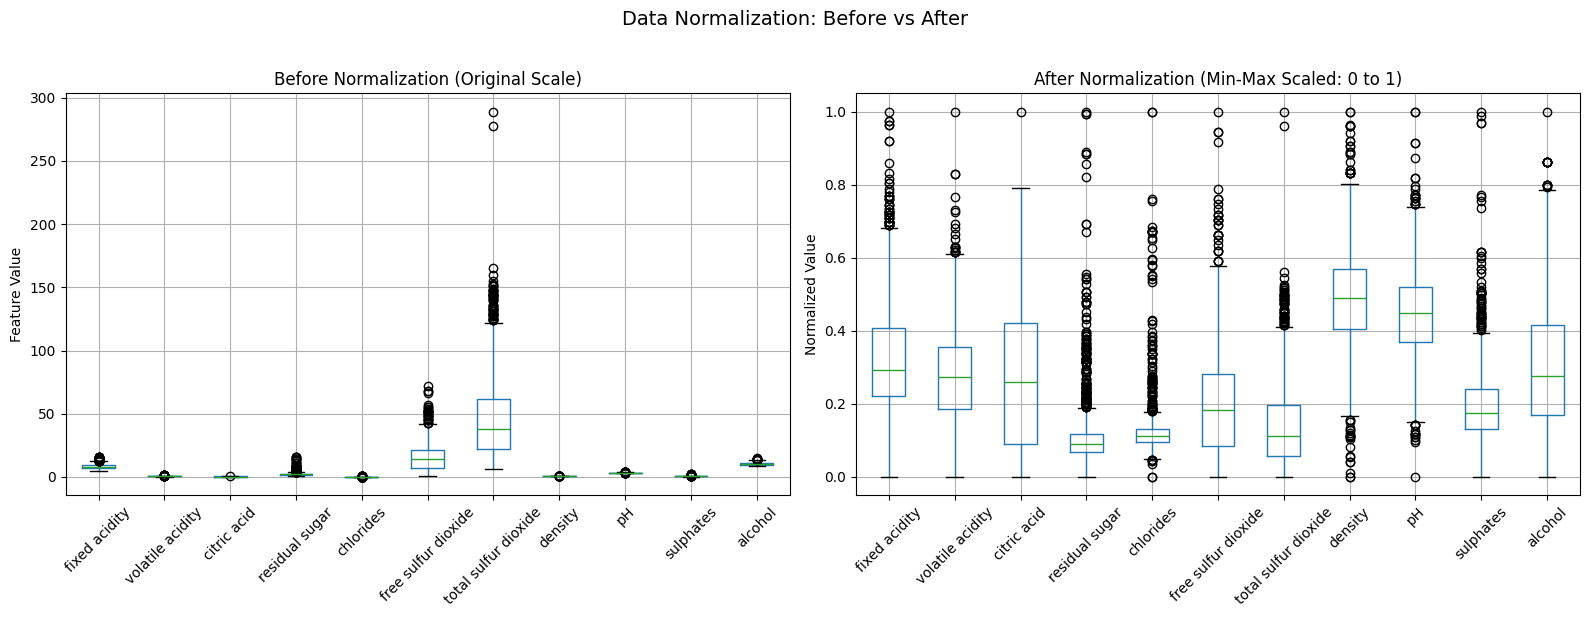


--------------------------------------------------------------------------------
These two Boxplots show the effect of Min-Max Normalization on the dataset.
LEFT = original scales where some features span hundreds of units and others
span less than 1.
RIGHT = after scaling, all features are brought to the same 0 to 1 range.
This prevents features with large numeric values from unfairly dominating the
model.
--------------------------------------------------------------------------------


  Polynomial Logistic Regression



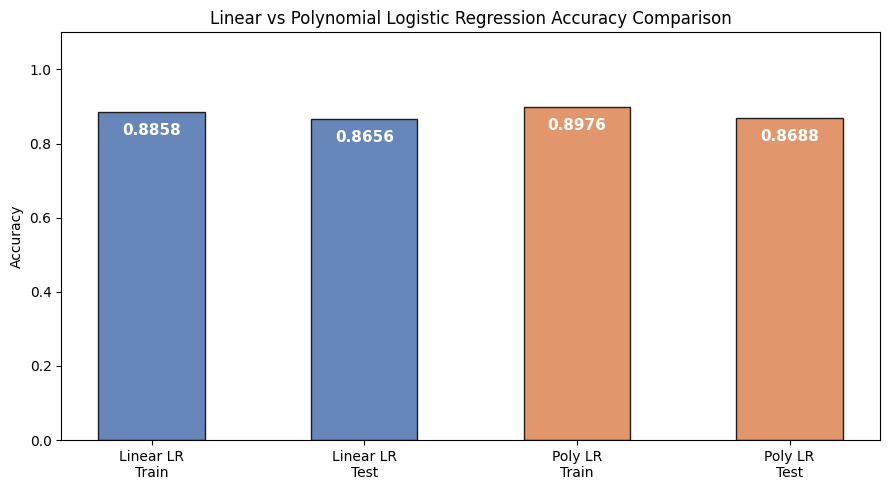


--------------------------------------------------------------------------------
This Bar Chart compares standard Linear LR (blue) vs Polynomial LR degree-2
(orange) on train and test data.
Linear LR learns only straight-line boundaries. Polynomial LR learns curved
boundaries using feature interactions.
If Polynomial test accuracy is higher, the data has non-linear patterns the
standard model was missing.
--------------------------------------------------------------------------------

Linear  -- Train: 0.8858 | Test: 0.8656
Poly*2  -- Train: 0.8976 | Test: 0.8688

  Error Analysis



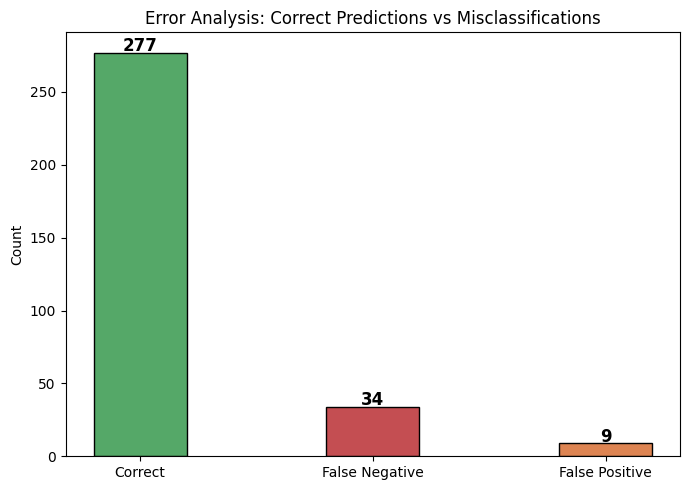


--------------------------------------------------------------------------------
This Bar Chart breaks down all test predictions into three outcome groups.
Correct (green) = model predicted the right class.
False Positive (orange) = Bad wine wrongly predicted as Good.
False Negative (red) = Good wine wrongly predicted as Bad — the most costly
error in quality control.
--------------------------------------------------------------------------------



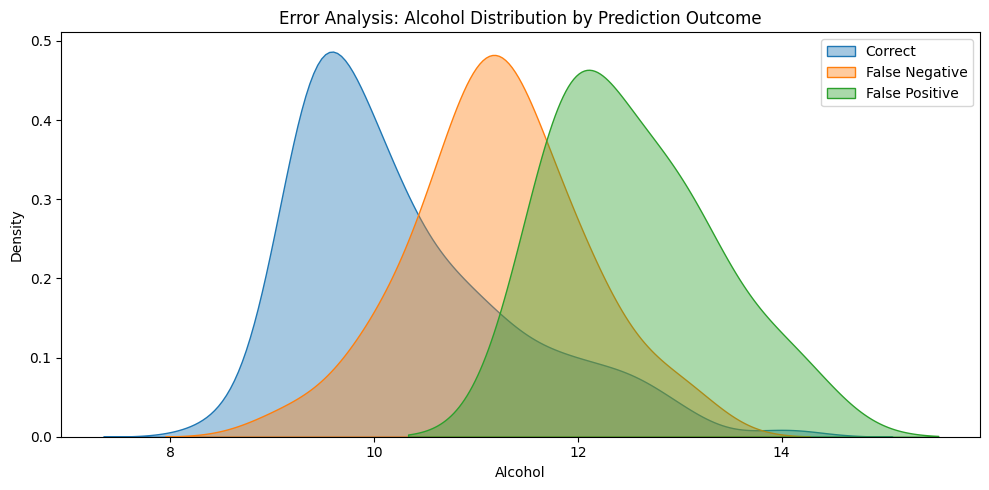


--------------------------------------------------------------------------------
This KDE Plot zooms into the alcohol feature and shows at which alcohol levels
the model makes mistakes.
If the False Negative curve peaks at high alcohol = model struggles to identify
Good wines with high alcohol.
If curves heavily overlap = alcohol alone cannot reliably explain why certain
wines are being misclassified.
--------------------------------------------------------------------------------


  Scatterplot Matrix



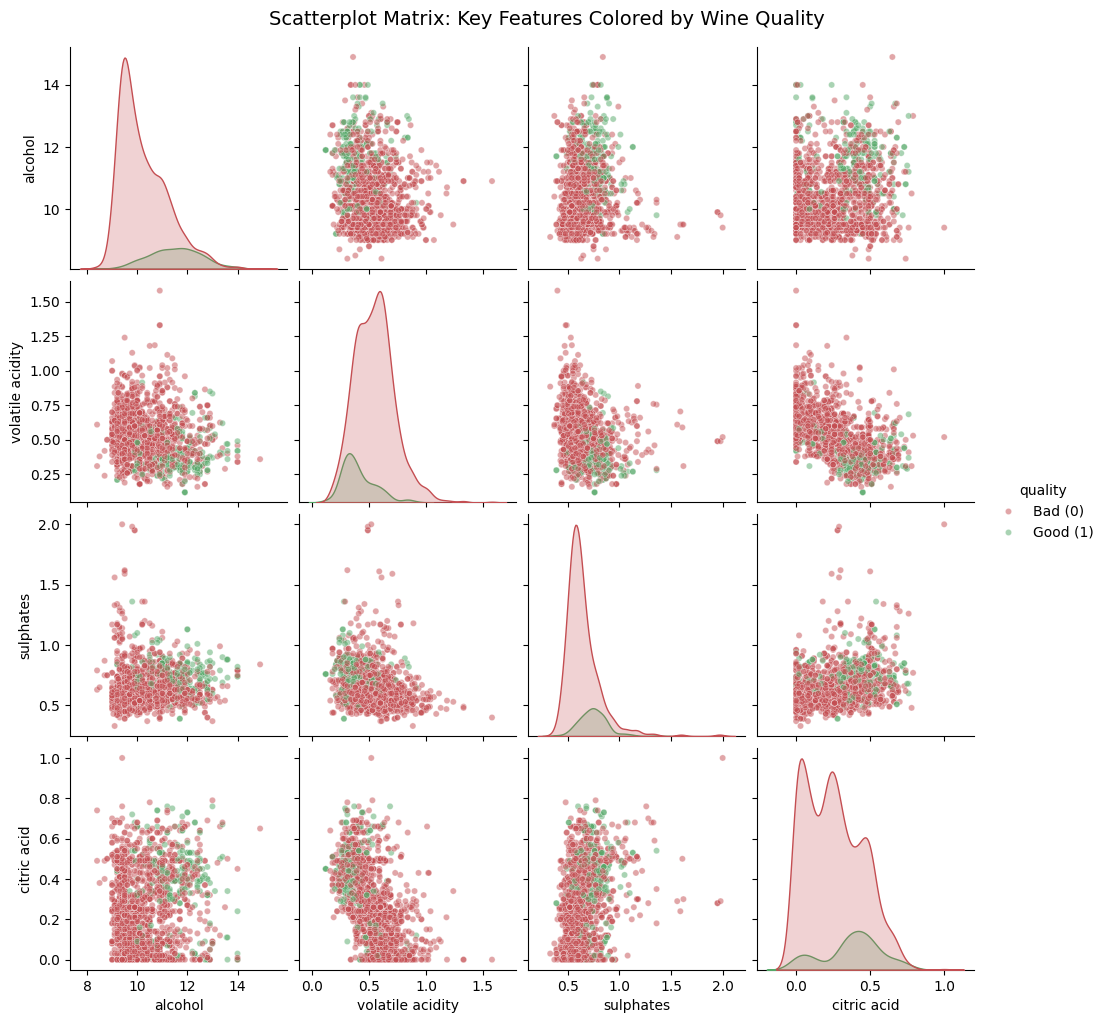


--------------------------------------------------------------------------------
This Scatterplot Matrix plots every pair combination of selected features
against each other.
Green dots = Good wine | Red dots = Bad wine | Diagonal = KDE distribution for
each feature individually.
Clearly separated Red and Green clusters in a cell = those two features together
are strong quality predictors.
Heavy color overlap in a cell = those two features combined are not enough to
separate the wine classes.
--------------------------------------------------------------------------------


  Learning Curve



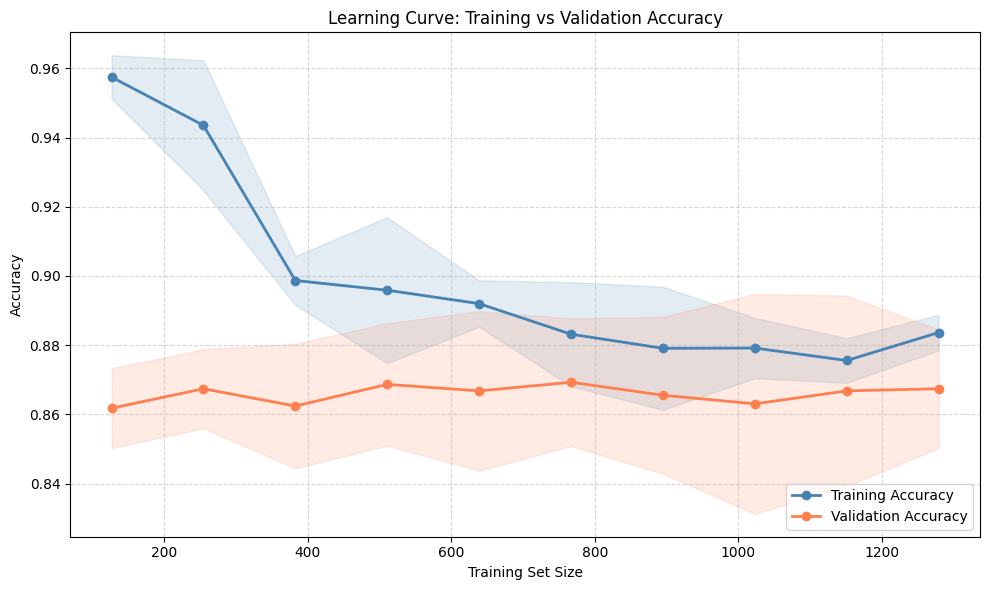


--------------------------------------------------------------------------------
This Learning Curve shows how training and validation accuracy change as the
model sees more data.
If training accuracy is high but validation is low across all sizes = the model
is overfitting.
If both curves converge to a low value = underfitting — the model needs more
complexity or better features.
Ideally both curves should converge close together at a high accuracy value as
training size grows.
--------------------------------------------------------------------------------


  Model Comparison Section



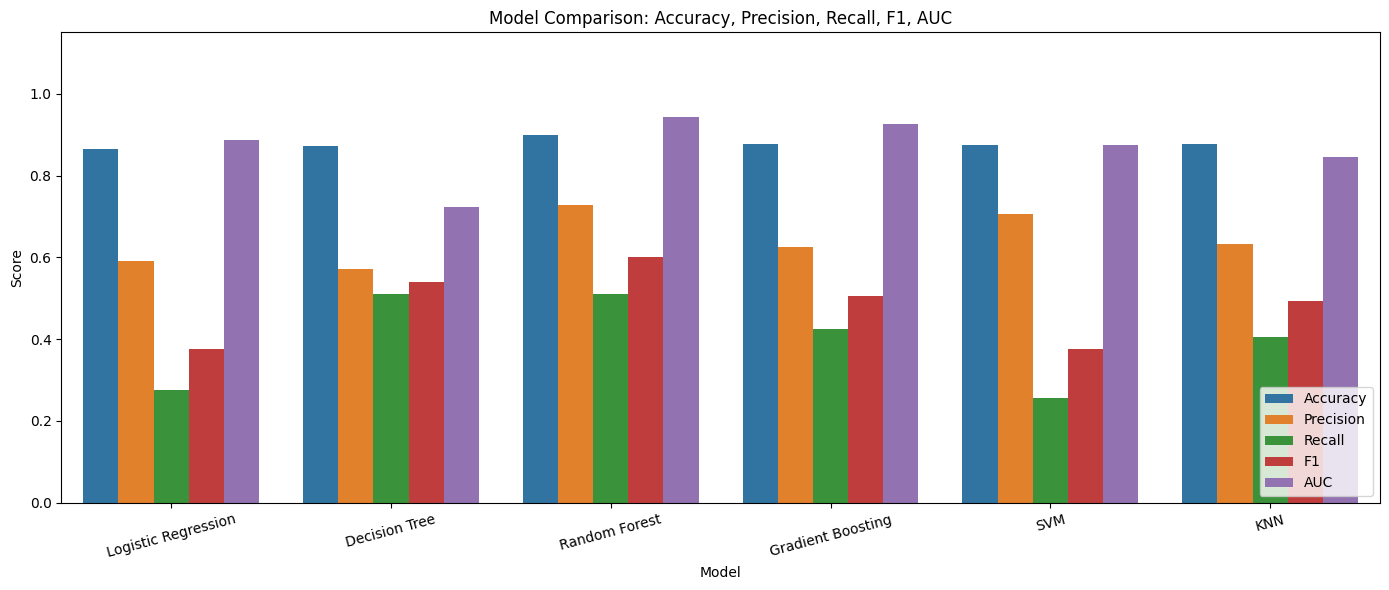

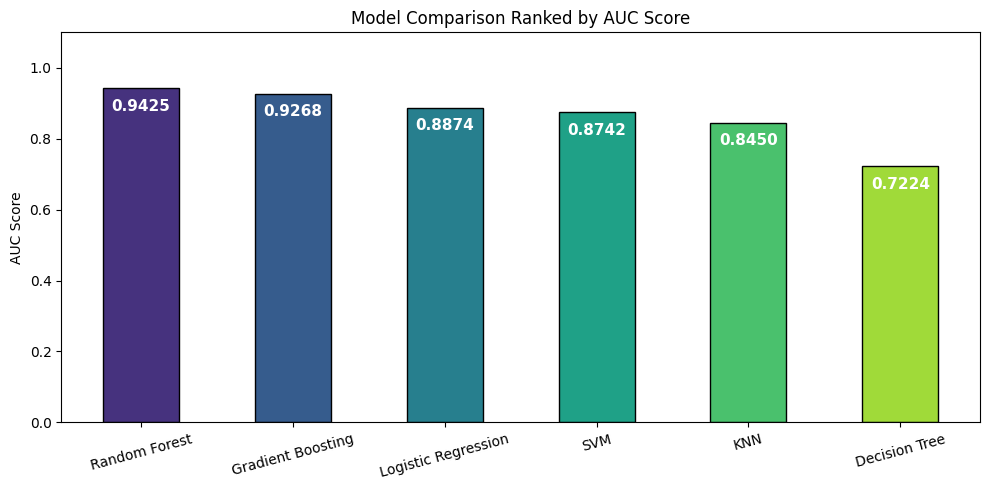


--------------------------------------------------------------------------------
These charts compare six classification models on all key performance metrics.
The grouped bar chart shows Accuracy, Precision, Recall, F1, and AUC side by
side for every model.
The ranked AUC chart highlights which model best separates Good wines from Bad
wines overall.
Use this section to pick the best-performing model before deploying to
production.
--------------------------------------------------------------------------------

                     Accuracy  Precision    Recall        F1       AUC
Model                                                                 
Logistic Regression  0.865625   0.590909  0.276596  0.376812  0.887382
Decision Tree        0.871875   0.571429  0.510638  0.539326  0.722352
Random Forest        0.900000   0.727273  0.510638  0.600000  0.942522
Gradient Boosting    0.878125   0.625000  0.425532  0.506329  0.926818
SVM                  0.875000   0.705882  0.255319  0.3

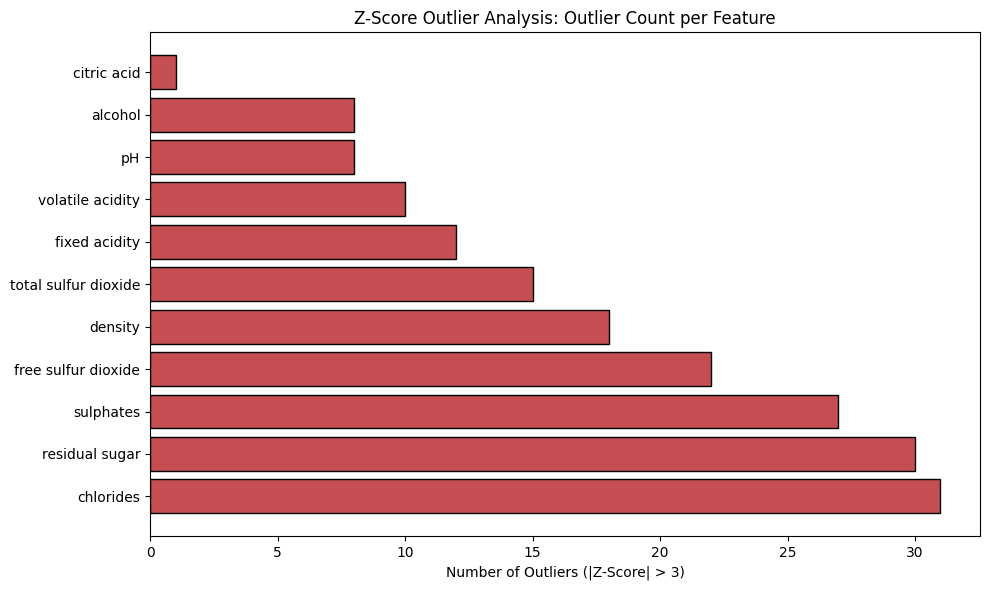

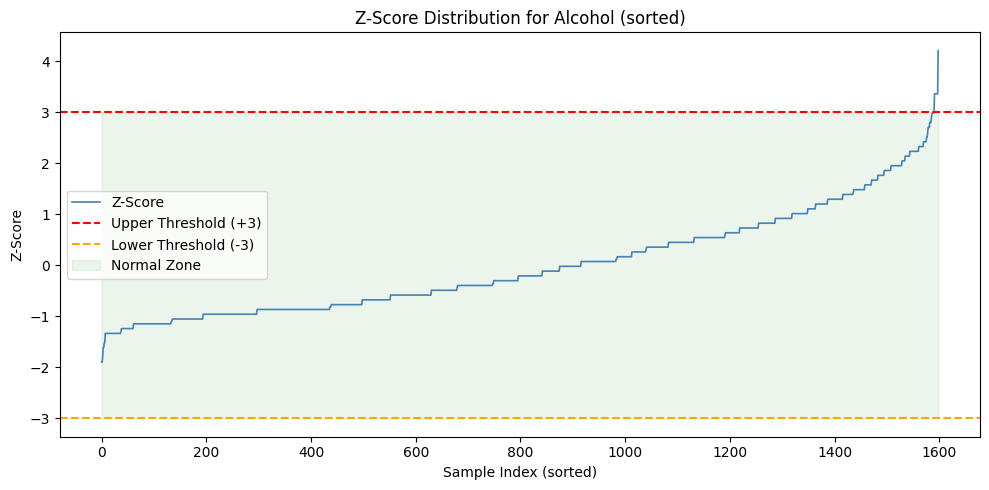


--------------------------------------------------------------------------------
Z-Score measures how many standard deviations away each data point is from the
feature mean.
Any sample with |Z-Score| > 3 is flagged as a statistical outlier for that
feature.
The bar chart shows which features have the most outliers in the dataset.
The line chart shows the sorted Z-Score spread for the alcohol feature — points
outside the red lines are outliers.
Total samples flagged as outliers (at least one feature with |Z|>3): 141 out of
1599.
--------------------------------------------------------------------------------

             Feature  Outlier_Count
           chlorides             31
      residual sugar             30
           sulphates             27
 free sulfur dioxide             22
             density             18
total sulfur dioxide             15
       fixed acidity             12
    volatile acidity             10
                  pH              8
             alcohol   

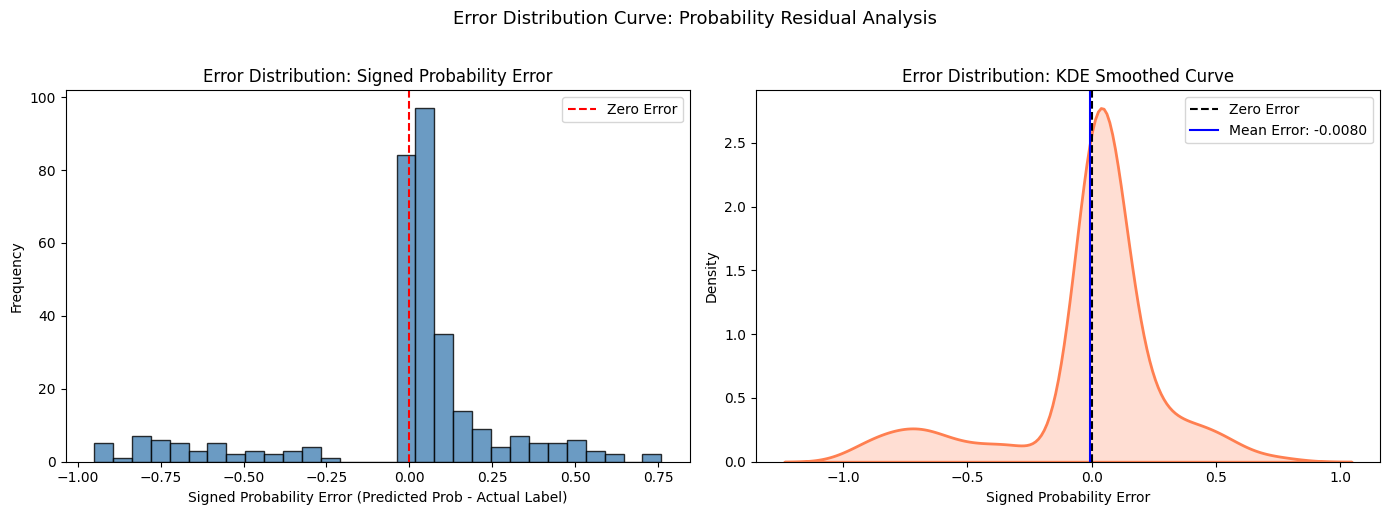


--------------------------------------------------------------------------------
These plots analyze the distribution of prediction errors produced by the model.
Error = Predicted Probability - Actual Label (0 or 1). Errors near 0 = confident
correct predictions.
The histogram shows the raw frequency of each error magnitude across all test
samples.
The KDE curve smooths this into a probability density — a sharp peak near zero =
well-calibrated model.
Skew towards negative = model underestimates Good wines | Skew towards positive
= model overestimates.
--------------------------------------------------------------------------------

Mean Error : -0.0080
Std Dev    : 0.3018
Max Error  : 0.7597
Min Error  : -0.9507

  Feature Engineering



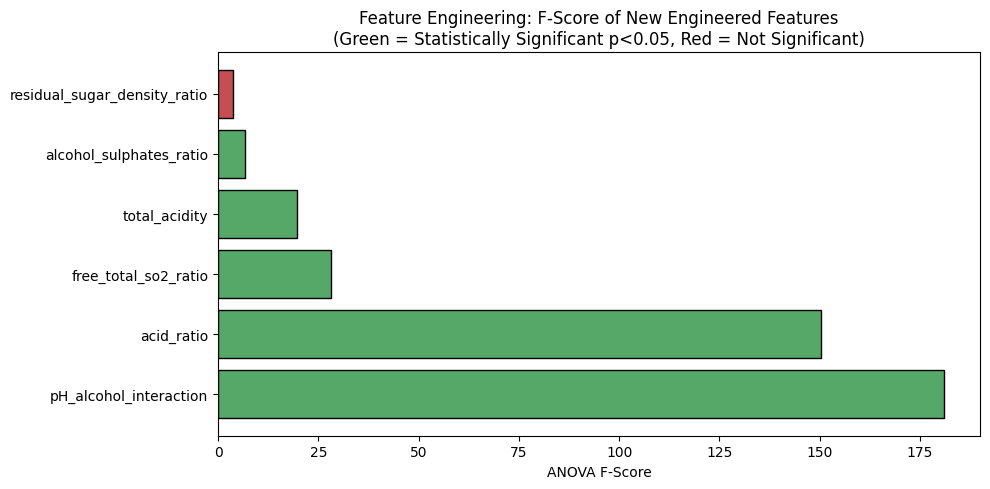

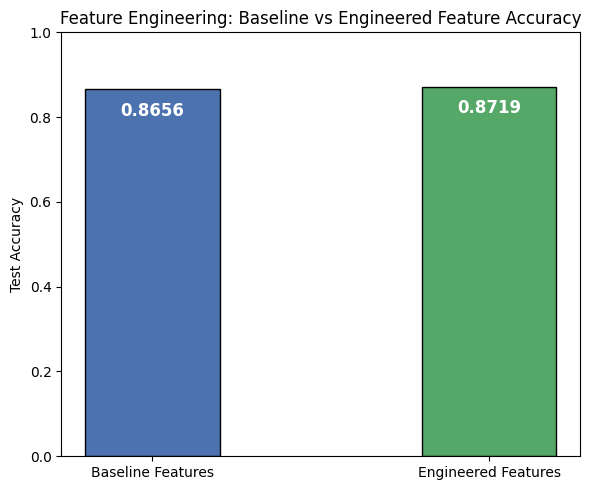


--------------------------------------------------------------------------------
This section creates six new features by combining existing ones through ratios
and interactions.
alcohol_sulphates_ratio = combines two top predictors into a single signal.
acid_ratio = captures the balance between fixed and volatile acidity.
total_acidity = sums all acid-related features into one composite measure.
The F-Score bar chart shows which engineered features have statistically
significant predictive power.
The accuracy comparison chart shows whether adding these features improves the
model's test performance.
--------------------------------------------------------------------------------

                     Feature    F-Score      P-Value
      pH_alcohol_interaction 180.926489 3.774558e-39
                  acid_ratio 150.362089 4.228889e-33
        free_total_so2_ratio  28.081674 1.325292e-07
               total_acidity  19.716516 9.598671e-06
     alcohol_sulphates_ratio   6.801443 9.19

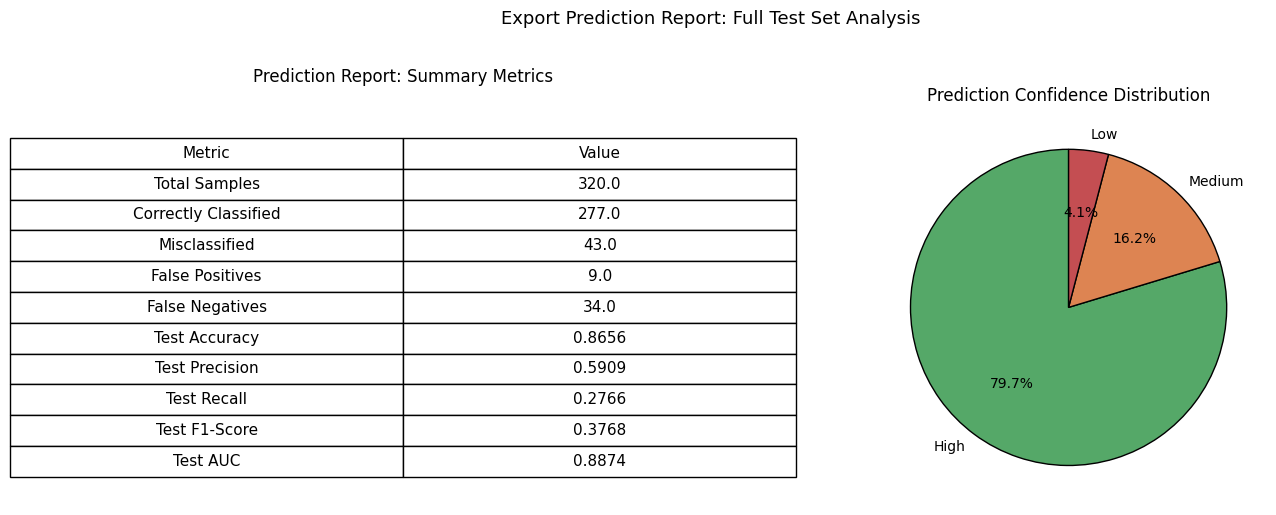


--------------------------------------------------------------------------------
This section builds a full prediction report for every sample in the test set.
Each row includes the original feature values, actual label, predicted label,
probability, and error type.
A confidence level is assigned based on how far the predicted probability is
from the 0.5 threshold.
The summary metrics table provides a one-page snapshot of the model's overall
test performance.
The pie chart shows the proportion of High, Medium, and Low confidence
predictions made by the model.
The complete prediction report has been saved to:
/content/wine_prediction_report.csv
--------------------------------------------------------------------------------

              Metric    Value
       Total Samples 320.0000
Correctly Classified 277.0000
       Misclassified  43.0000
     False Positives   9.0000
     False Negatives  34.0000
       Test Accuracy   0.8656
      Test Precision   0.5909
         Test Recall   0.

In [2]:
# ==============================
# WINE QUALITY PREDICTION PROJECT
# ==============================

# ==============================
# IMPORT LIBRARIES
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap
import os

from scipy import stats

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold, learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, roc_auc_score, precision_recall_curve,
    precision_score, recall_score, f1_score
)
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif, RFE

# ==============================
# HELPER FUNCTIONS
# ==============================
def section_break(title):
    print("\n" + "="*80)
    print(f"  {title}")
    print("="*80 + "\n")

def explain(text):
    width = 80
    print("\n" + "-"*width)
    lines = text.strip().split("\n")
    for line in lines:
        wrapped = textwrap.fill(line.strip(), width=width)
        print(wrapped)
    print("-"*width + "\n")

# ==============================
# LOAD DATASET
# ==============================
df = pd.read_csv('/content/winequality-red.csv')

print("\nDataset Loaded Successfully!\n")
print(df.head())

# ==============================
# DATA UNDERSTANDING
# ==============================
print("\nDataset Info:\n")
print(df.info())

print("\nMissing Values:\n")
print(df.isnull().sum())

# ==============================
# TARGET CONVERSION
# ==============================
df['quality'] = df['quality'].apply(lambda x: 1 if x >= 7 else 0)

print("\nTarget Distribution:\n")
print(df['quality'].value_counts())

# ==============================
# SPLIT DATA
# ==============================
X = df.drop('quality', axis=1)
y = df['quality']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# FEATURE SCALING
# ==============================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# ==============================
# 1. TARGET DISTRIBUTION
# ==============================
section_break("Target Distribution")

sns.countplot(x='quality', data=df)
plt.title("Wine Quality Distribution (0 = Bad, 1 = Good)")
plt.tight_layout()
plt.show()

explain(
    "This Count Plot shows how many wines are labeled Bad (0) and Good (1).\n"
    "It helps us understand whether the dataset is balanced or imbalanced between the two classes.\n"
    "A large gap between bars means the model may be biased towards the majority class."
)

# ==============================
# 2. CORRELATION HEATMAP
# ==============================
section_break("Correlation Heatmap")

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.tight_layout()
plt.show()

explain(
    "This Heatmap displays the Pearson correlation between every pair of features.\n"
    "Values close to +1 = strong positive relationship | Values close to -1 = strong negative relationship | Near 0 = no linear relationship.\n"
    "Use this to spot which features are most strongly correlated with wine quality (last row/column)."
)

# ==============================
# 3. FEATURE DISTRIBUTIONS
# ==============================
section_break("Feature Distributions")

df.hist(figsize=(15,10), bins=20)
plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.show()

explain(
    "These Histograms show how values of each individual feature are distributed across the dataset.\n"
    "A bell-shaped curve suggests normal distribution. Skewed bars indicate outliers or uneven spread.\n"
    "Both skewness and outliers can affect model performance and may require preprocessing."
)

# ==============================
# 4. BOXPLOTS
# ==============================
section_break("Boxplots")

plt.figure(figsize=(15,8))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title("Boxplot of Features")
plt.tight_layout()
plt.show()

explain(
    "These Boxplots display the median, spread (IQR), and outliers for each feature.\n"
    "The box = middle 50% of data | Line inside box = median | Dots beyond the whiskers = outliers.\n"
    "Features with many outlier dots may need treatment before being fed into the model."
)

# ==============================
# MODEL TRAINING
# ==============================
section_break("Model Training")

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Model trained successfully!")

# ==============================
# PREDICTIONS
# ==============================
section_break("Predictions")

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

# ==============================
# 5. CONFUSION MATRIX
# ==============================
section_break("Confusion Matrix")

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

explain(
    "This Confusion Matrix shows 4 prediction outcomes of the model.\n"
    "True Positive = correctly predicted Good | True Negative = correctly predicted Bad.\n"
    "False Positive = Bad wine wrongly called Good | False Negative = Good wine wrongly called Bad.\n"
    "Higher values on the diagonal (top-left to bottom-right) = better model performance."
)

# ==============================
# 6. CLASSIFICATION REPORT
# ==============================
section_break("Classification Report")

print(classification_report(y_test, y_pred))

# ==============================
# 7. ROC CURVE
# ==============================
section_break("ROC Curve")

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

explain(
    "This ROC Curve plots True Positive Rate vs False Positive Rate at every possible decision threshold.\n"
    "The closer the curve hugs the top-left corner, the better the model is at distinguishing Good from Bad wine.\n"
    "The dashed diagonal line = random guess baseline. A curve above it = model is better than random."
)

print("AUC Score:", roc_auc_score(y_test, y_prob))

# ==============================
# 8. PRECISION-RECALL CURVE
# ==============================
section_break("Precision-Recall Curve")

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.tight_layout()
plt.show()

explain(
    "This Precision-Recall Curve is especially useful when the dataset is imbalanced.\n"
    "Precision = of all wines predicted Good, how many actually were Good.\n"
    "Recall = of all actual Good wines, how many did the model successfully catch.\n"
    "A curve that stays high on both axes indicates a strong and reliable model."
)

# ==============================
# 9. THRESHOLD vs ACCURACY
# ==============================
section_break("Threshold vs Accuracy")

thresholds = np.arange(0.0, 1.0, 0.01)
accuracies = []

for t in thresholds:
    y_pred_thresh = (y_prob >= t).astype(int)
    acc = accuracy_score(y_test, y_pred_thresh)
    accuracies.append(acc)

plt.plot(thresholds, accuracies)
plt.xlabel("Threshold")
plt.ylabel("Accuracy")
plt.title("Threshold vs Accuracy")
plt.tight_layout()
plt.show()

explain(
    "This Line Plot shows how overall accuracy changes as the decision threshold shifts from 0 to 1.\n"
    "By default the model uses 0.5 as the cutoff to decide Good vs Bad wine.\n"
    "The peak of this curve shows the optimal threshold that gives the highest accuracy for this dataset."
)

# ==============================
# 10. FEATURE IMPORTANCE
# ==============================
section_break("Feature Importance")

importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

sns.barplot(x='Coefficient', y='Feature', data=importance)
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

explain(
    "This Bar Plot ranks each feature by its Logistic Regression coefficient value.\n"
    "Large positive value = that feature strongly pushes the prediction towards Good wine.\n"
    "Large negative value = that feature strongly pushes the prediction towards Bad wine.\n"
    "Features near zero have very little influence on the model's final decision."
)

# ==============================
# 11. FEATURE vs TARGET
# ==============================
section_break("Feature vs Target Distribution")

features = ['alcohol', 'pH', 'citric acid']

for feature in features:
    sns.kdeplot(data=df, x=feature, hue='quality', fill=True)
    plt.title(f"{feature} vs Quality")
    plt.tight_layout()
    plt.show()

    explain(
        f"This KDE Plot shows the probability distribution of '{feature}' for Bad (0) and Good (1) wines.\n"
        f"Where the two curves are far apart, '{feature}' is a strong separator between the two classes.\n"
        f"Where the curves heavily overlap, '{feature}' alone is not enough to distinguish wine quality."
    )

# ==============================
# 12. PAIRPLOT
# ==============================
section_break("Pairplot")

selected_features = ['alcohol', 'volatile acidity', 'citric acid', 'quality']
sns.pairplot(df[selected_features], hue='quality')
plt.show()

explain(
    "This Pairplot Matrix shows every combination of scatter plots between the selected features.\n"
    "Each dot is colored by wine quality class. Diagonal plots show individual feature distributions.\n"
    "Clusters clearly separated by color = those two features together are strong predictors of wine quality."
)

# ==============================
# 13. SIGMOID FUNCTION
# ==============================
section_break("Sigmoid Function")

z = np.linspace(-10, 10, 100)
sigmoid = 1 / (1 + np.exp(-z))

plt.plot(z, sigmoid)
plt.xlabel("z")
plt.ylabel("Sigmoid(z)")
plt.title("Sigmoid Function")
plt.tight_layout()
plt.show()

explain(
    "This curve shows the Sigmoid (Logistic) Function — the mathematical backbone of Logistic Regression.\n"
    "It converts any raw numeric input (z) into a probability value between 0 and 1.\n"
    "Output above 0.5 = model predicts Good wine (1) | Output below 0.5 = model predicts Bad wine (0)."
)

# ==============================
# 14. TRAIN-TEST ACCURACY COMPARISON
# ==============================
section_break("Train-Test Accuracy Comparison")

train_acc = accuracy_score(y_train, model.predict(X_train))
test_acc  = accuracy_score(y_test,  y_pred)

plt.figure(figsize=(6, 5))
bars = plt.bar(['Train Accuracy', 'Test Accuracy'], [train_acc, test_acc],
               color=['steelblue', 'coral'], edgecolor='black', width=0.4)
for bar, val in zip(bars, [train_acc, test_acc]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.03,
             f"{val:.4f}", ha='center', va='top', fontsize=12, color='white', fontweight='bold')
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy Comparison")
plt.tight_layout()
plt.show()

explain(
    "This Bar Chart compares model accuracy on training data vs completely unseen test data.\n"
    "Train Accuracy much higher than Test Accuracy = overfitting (model memorized instead of learning).\n"
    "Both similarly low = underfitting. Ideally both bars should be high and close to each other."
)
print(f"Train Accuracy: {train_acc:.4f}  |  Test Accuracy: {test_acc:.4f}")

# ==============================
# 15. CROSS VALIDATION
# ==============================
section_break("Cross Validation")

cv_model = LogisticRegression(max_iter=1000)
X_scaled_full = scaler.fit_transform(X)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = cross_val_score(cv_model, X_scaled_full, y, cv=cv, scoring='accuracy')

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), cv_scores, marker='o', color='steelblue', linewidth=2, markersize=8)
plt.axhline(y=cv_scores.mean(), color='red', linestyle='--', label=f'Mean Accuracy: {cv_scores.mean():.4f}')
plt.fill_between(range(1, 11), cv_scores.mean() - cv_scores.std(),
                 cv_scores.mean() + cv_scores.std(), alpha=0.2, color='steelblue')
plt.xlabel("Fold Number")
plt.ylabel("Accuracy")
plt.title("10-Fold Stratified Cross Validation Accuracy")
plt.xticks(range(1, 11))
plt.legend()
plt.tight_layout()
plt.show()

explain(
    "This Line Plot shows the model's accuracy across 10 different train-test splits of the entire dataset.\n"
    "Each point = accuracy for one fold | Red dashed line = mean accuracy | Shaded band = standard deviation.\n"
    "A stable flat line with small fluctuations = model generalizes consistently and is not dependent on one lucky split."
)
print(f"CV Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}  |  Std Dev: {cv_scores.std():.4f}")

# ==============================
# 16. HYPERPARAMETER TUNING
# ==============================
section_break("Hyperparameter Tuning")

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear'],
    'penalty': ['l2']
}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)
grid_search.fit(X_scaled_full, y)

results_df = pd.DataFrame(grid_search.cv_results_)
pivot = results_df[results_df['param_solver'] == 'lbfgs'].pivot_table(
    index='param_C', values='mean_test_score'
)

plt.figure(figsize=(8, 5))
plt.plot(pivot.index.astype(str), pivot['mean_test_score'], marker='o', color='darkorange', linewidth=2)
plt.xlabel("Regularization Parameter C")
plt.ylabel("Mean CV Accuracy")
plt.title("Hyperparameter Tuning: C vs Accuracy (lbfgs solver)")
plt.tight_layout()
plt.show()

explain(
    "This Line Plot shows how model accuracy changes as regularization parameter C is varied.\n"
    "Small C = strong regularization (simpler model, may underfit) | Large C = weak regularization (may overfit).\n"
    "The peak of the curve is the best value of C — giving the highest accuracy without overfitting."
)
print(f"Best Parameters : {grid_search.best_params_}")
print(f"Best CV Accuracy: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

# ==============================
# 17. DECISION BOUNDARY VISUALIZATION
# ==============================
section_break("Decision Boundary Visualization")

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_full)

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)

boundary_model = LogisticRegression(max_iter=1000)
boundary_model.fit(X_train_pca, y_train_pca)

x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

Z = boundary_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='RdBu', edgecolors='k', s=20, alpha=0.7)
plt.colorbar(scatter, label='Quality (0=Bad, 1=Good)')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Decision Boundary Visualization (PCA Reduced to 2D)")
plt.tight_layout()
plt.show()

explain(
    "This plot shows WHERE the model draws its decision line to separate Good wines from Bad wines.\n"
    "PCA compressed all 11 features into 2 dimensions so the boundary can be visualized on a 2D plane.\n"
    "Each dot = one wine sample | Background color = model's predicted class for that region.\n"
    "Dots sitting on the wrong background color = misclassified samples."
)

# ==============================
# 18. PRECISION-RECALL-F1 BAR GRAPH
# ==============================
section_break("Precision-Recall-F1 Bar Graph")

prec  = precision_score(y_test, y_pred)
rec   = recall_score(y_test, y_pred)
f1    = f1_score(y_test, y_pred)
acc   = accuracy_score(y_test, y_pred)

metrics       = ['Precision', 'Recall', 'F1-Score', 'Accuracy']
metric_values = [prec, rec, f1, acc]
colors        = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

plt.figure(figsize=(8, 5))
bars = plt.bar(metrics, metric_values, color=colors, edgecolor='black', width=0.5)
for bar, val in zip(bars, metric_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.04,
             f"{val:.4f}", ha='center', va='top', fontsize=12, color='white', fontweight='bold')
plt.ylim(0, 1.1)
plt.ylabel("Score")
plt.title("Precision, Recall, F1-Score & Accuracy Bar Graph")
plt.tight_layout()
plt.show()

explain(
    "This Bar Chart shows all four key classification metrics side by side in one single view.\n"
    "Precision = of all predicted Good wines, how many were actually Good.\n"
    "Recall = of all actual Good wines, how many did the model catch.\n"
    "F1-Score = harmonic balance between Precision and Recall | Accuracy = total correct out of all predictions."
)
print(f"Precision: {prec:.4f}  |  Recall: {rec:.4f}  |  F1-Score: {f1:.4f}  |  Accuracy: {acc:.4f}")

# ==============================
# 19. FEATURE SELECTION
# ==============================
section_break("Feature Selection")

selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X, y)

feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector.scores_
}).sort_values(by='Score', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Score', y='Feature', data=feature_scores, palette='viridis')
plt.title("Feature Selection: ANOVA F-Score (SelectKBest)")
plt.xlabel("F-Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

explain(
    "This Bar Chart ranks every feature using the ANOVA F-Score statistical method.\n"
    "A higher F-Score means that feature's values differ significantly between Good and Bad wine classes.\n"
    "Features at the top are statistically most useful for prediction. Features at the bottom contribute very little."
)
print(feature_scores.to_string(index=False))

rfe = RFE(LogisticRegression(max_iter=1000), n_features_to_select=6)
rfe.fit(X_scaled_full, y)
rfe_support = pd.DataFrame({
    'Feature': X.columns,
    'Selected': rfe.support_,
    'Ranking' : rfe.ranking_
}).sort_values('Ranking')
print("\nRFE Feature Ranking:\n")
print(rfe_support.to_string(index=False))

# ==============================
# 20. COEFFICIENT ANALYSIS
# ==============================
section_break("Coefficient Analysis")

coef_df = pd.DataFrame({
    'Feature'    : X.columns,
    'Coefficient': model.coef_[0],
    'Abs_Coef'   : np.abs(model.coef_[0])
}).sort_values(by='Coefficient')

colors_coef = ['#C44E52' if c < 0 else '#55A868' for c in coef_df['Coefficient']]

plt.figure(figsize=(10, 6))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors_coef, edgecolor='black')
plt.axvline(x=0, color='black', linewidth=1.2, linestyle='--')
plt.xlabel("Coefficient Value")
plt.title("Coefficient Analysis: Positive (Green) vs Negative (Red) Impact on Quality")
plt.tight_layout()
plt.show()

explain(
    "This Horizontal Bar Chart shows exactly how each feature pushes the model's prediction.\n"
    "Green bars (positive) = higher values of that feature push prediction towards Good wine.\n"
    "Red bars (negative) = higher values of that feature push prediction towards Bad wine.\n"
    "The longer the bar in either direction, the stronger that feature's influence on the model."
)
print(coef_df[['Feature', 'Coefficient', 'Abs_Coef']].sort_values('Abs_Coef', ascending=False).to_string(index=False))

# ==============================
# 21. CORRELATION ANALYSIS
# ==============================
section_break("Correlation Analysis")

corr_with_target = df.corr()['quality'].drop('quality').sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors_corr = ['#55A868' if v > 0 else '#C44E52' for v in corr_with_target]
plt.barh(corr_with_target.index, corr_with_target.values, color=colors_corr, edgecolor='black')
plt.axvline(x=0, color='black', linewidth=1.2, linestyle='--')
plt.xlabel("Pearson Correlation with Quality")
plt.title("Correlation Analysis: Feature Correlation with Target (Quality)")
plt.tight_layout()
plt.show()

explain(
    "This Horizontal Bar Chart shows the direct linear relationship between each feature and wine quality.\n"
    "Green bars = that feature tends to increase as wine quality increases (positive correlation).\n"
    "Red bars = that feature tends to decrease as wine quality increases (negative correlation).\n"
    "Longer bars in either direction = stronger link to wine quality = more valuable for the model."
)
print(corr_with_target)

# ==============================
# 22. DATA NORMALIZATION
# ==============================
section_break("Data Normalization")

minmax_scaler = MinMaxScaler()
X_normalized  = minmax_scaler.fit_transform(X)
X_norm_df     = pd.DataFrame(X_normalized, columns=X.columns)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

X.boxplot(ax=axes[0], rot=45)
axes[0].set_title("Before Normalization (Original Scale)")
axes[0].set_ylabel("Feature Value")

X_norm_df.boxplot(ax=axes[1], rot=45)
axes[1].set_title("After Normalization (Min-Max Scaled: 0 to 1)")
axes[1].set_ylabel("Normalized Value")

plt.suptitle("Data Normalization: Before vs After", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

explain(
    "These two Boxplots show the effect of Min-Max Normalization on the dataset.\n"
    "LEFT = original scales where some features span hundreds of units and others span less than 1.\n"
    "RIGHT = after scaling, all features are brought to the same 0 to 1 range.\n"
    "This prevents features with large numeric values from unfairly dominating the model."
)

# ==============================
# 23. POLYNOMIAL LOGISTIC REGRESSION
# ==============================
section_break("Polynomial Logistic Regression")

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly_full = poly.fit_transform(X_scaled_full)

X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(
    X_poly_full, y, test_size=0.2, random_state=42
)

poly_model = LogisticRegression(max_iter=2000, C=0.1)
poly_model.fit(X_train_poly, y_train_poly)

poly_train_acc = accuracy_score(y_train_poly, poly_model.predict(X_train_poly))
poly_test_acc  = accuracy_score(y_test_poly,  poly_model.predict(X_test_poly))

plain_train_acc = accuracy_score(y_train, model.predict(X_train))
plain_test_acc  = accuracy_score(y_test,  y_pred)

labels = ['Linear LR\nTrain', 'Linear LR\nTest', 'Poly LR\nTrain', 'Poly LR\nTest']
values = [plain_train_acc, plain_test_acc, poly_train_acc, poly_test_acc]
colors_poly = ['#4C72B0', '#4C72B0', '#DD8452', '#DD8452']

plt.figure(figsize=(9, 5))
bars = plt.bar(labels, values, color=colors_poly, edgecolor='black', width=0.5, alpha=0.85)
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.03,
             f"{val:.4f}", ha='center', va='top', fontsize=11, color='white', fontweight='bold')
plt.ylim(0, 1.1)
plt.ylabel("Accuracy")
plt.title("Linear vs Polynomial Logistic Regression Accuracy Comparison")
plt.tight_layout()
plt.show()

explain(
    "This Bar Chart compares standard Linear LR (blue) vs Polynomial LR degree-2 (orange) on train and test data.\n"
    "Linear LR learns only straight-line boundaries. Polynomial LR learns curved boundaries using feature interactions.\n"
    "If Polynomial test accuracy is higher, the data has non-linear patterns the standard model was missing."
)
print(f"Linear  -- Train: {plain_train_acc:.4f} | Test: {plain_test_acc:.4f}")
print(f"Poly*2  -- Train: {poly_train_acc:.4f} | Test: {poly_test_acc:.4f}")

# ==============================
# 24. ERROR ANALYSIS
# ==============================
section_break("Error Analysis")

X_test_original = scaler.inverse_transform(X_test)
error_df = pd.DataFrame(X_test_original, columns=X.columns)
error_df['Actual']     = y_test.values
error_df['Predicted']  = y_pred
error_df['Error_Type'] = 'Correct'
error_df.loc[(error_df['Actual'] == 1) & (error_df['Predicted'] == 0), 'Error_Type'] = 'False Negative'
error_df.loc[(error_df['Actual'] == 0) & (error_df['Predicted'] == 1), 'Error_Type'] = 'False Positive'

error_counts = error_df['Error_Type'].value_counts()

plt.figure(figsize=(7, 5))
colors_err = {'Correct': '#55A868', 'False Negative': '#C44E52', 'False Positive': '#DD8452'}
plt.bar(error_counts.index, error_counts.values,
        color=[colors_err[k] for k in error_counts.index], edgecolor='black', width=0.4)
for i, (label, val) in enumerate(error_counts.items()):
    plt.text(i, val + 1, str(val), ha='center', fontsize=12, fontweight='bold')
plt.ylabel("Count")
plt.title("Error Analysis: Correct Predictions vs Misclassifications")
plt.tight_layout()
plt.show()

explain(
    "This Bar Chart breaks down all test predictions into three outcome groups.\n"
    "Correct (green) = model predicted the right class.\n"
    "False Positive (orange) = Bad wine wrongly predicted as Good.\n"
    "False Negative (red) = Good wine wrongly predicted as Bad — the most costly error in quality control."
)

plt.figure(figsize=(10, 5))
sns.kdeplot(data=error_df[error_df['Error_Type'] == 'Correct'],        x='alcohol', label='Correct',        fill=True, alpha=0.4)
sns.kdeplot(data=error_df[error_df['Error_Type'] == 'False Negative'],  x='alcohol', label='False Negative',  fill=True, alpha=0.4)
sns.kdeplot(data=error_df[error_df['Error_Type'] == 'False Positive'],  x='alcohol', label='False Positive',  fill=True, alpha=0.4)
plt.title("Error Analysis: Alcohol Distribution by Prediction Outcome")
plt.xlabel("Alcohol")
plt.legend()
plt.tight_layout()
plt.show()

explain(
    "This KDE Plot zooms into the alcohol feature and shows at which alcohol levels the model makes mistakes.\n"
    "If the False Negative curve peaks at high alcohol = model struggles to identify Good wines with high alcohol.\n"
    "If curves heavily overlap = alcohol alone cannot reliably explain why certain wines are being misclassified."
)

# ==============================
# 25. SCATTERPLOT MATRIX
# ==============================
section_break("Scatterplot Matrix")

scatter_features = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid', 'quality']
scatter_df = df[scatter_features].copy()
scatter_df['quality'] = scatter_df['quality'].map({0: 'Bad (0)', 1: 'Good (1)'})

pair_grid = sns.pairplot(
    scatter_df,
    hue='quality',
    palette={'Bad (0)': '#C44E52', 'Good (1)': '#55A868'},
    plot_kws={'alpha': 0.5, 's': 20},
    diag_kind='kde'
)
pair_grid.fig.suptitle("Scatterplot Matrix: Key Features Colored by Wine Quality", y=1.02, fontsize=14)
plt.show()

explain(
    "This Scatterplot Matrix plots every pair combination of selected features against each other.\n"
    "Green dots = Good wine | Red dots = Bad wine | Diagonal = KDE distribution for each feature individually.\n"
    "Clearly separated Red and Green clusters in a cell = those two features together are strong quality predictors.\n"
    "Heavy color overlap in a cell = those two features combined are not enough to separate the wine classes."
)

# ==============================
# 26. LEARNING CURVE
# ==============================
section_break("Learning Curve")

lc_model = LogisticRegression(max_iter=1000)
train_sizes, train_scores, val_scores = learning_curve(
    lc_model, X_scaled_full, y,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Training Accuracy', linewidth=2)
plt.plot(train_sizes, val_mean,   'o-', color='coral',     label='Validation Accuracy', linewidth=2)
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='steelblue')
plt.fill_between(train_sizes, val_mean   - val_std,   val_mean   + val_std,   alpha=0.15, color='coral')
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve: Training vs Validation Accuracy")
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

explain(
    "This Learning Curve shows how training and validation accuracy change as the model sees more data.\n"
    "If training accuracy is high but validation is low across all sizes = the model is overfitting.\n"
    "If both curves converge to a low value = underfitting — the model needs more complexity or better features.\n"
    "Ideally both curves should converge close together at a high accuracy value as training size grows."
)

# ==============================
# 27. MODEL COMPARISON SECTION
# ==============================
section_break("Model Comparison Section")

comparison_models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000),
    'Decision Tree'       : DecisionTreeClassifier(random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM'                 : SVC(probability=True, random_state=42),
    'KNN'                 : KNeighborsClassifier(n_neighbors=5)
}

X_tr_cmp, X_te_cmp, y_tr_cmp, y_te_cmp = train_test_split(
    X_scaled_full, y, test_size=0.2, random_state=42
)

comparison_results = {}
for name, clf in comparison_models.items():
    clf.fit(X_tr_cmp, y_tr_cmp)
    preds    = clf.predict(X_te_cmp)
    probs    = clf.predict_proba(X_te_cmp)[:, 1]
    comparison_results[name] = {
        'Accuracy' : accuracy_score(y_te_cmp, preds),
        'Precision': precision_score(y_te_cmp, preds),
        'Recall'   : recall_score(y_te_cmp, preds),
        'F1'       : f1_score(y_te_cmp, preds),
        'AUC'      : roc_auc_score(y_te_cmp, probs)
    }

comp_df = pd.DataFrame(comparison_results).T.reset_index().rename(columns={'index': 'Model'})

comp_melted = comp_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(14, 6))
sns.barplot(data=comp_melted, x='Model', y='Score', hue='Metric', palette='tab10')
plt.title("Model Comparison: Accuracy, Precision, Recall, F1, AUC")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.ylim(0, 1.15)
plt.tight_layout()
plt.show()

# AUC-only bar chart for clean ranking
plt.figure(figsize=(10, 5))
auc_df = comp_df.sort_values('AUC', ascending=False)
colors_cmp = sns.color_palette('viridis', len(auc_df))
bars = plt.bar(auc_df['Model'], auc_df['AUC'], color=colors_cmp, edgecolor='black', width=0.5)
for bar, val in zip(bars, auc_df['AUC']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.03,
             f"{val:.4f}", ha='center', va='top', fontsize=11, color='white', fontweight='bold')
plt.ylim(0, 1.1)
plt.ylabel("AUC Score")
plt.title("Model Comparison Ranked by AUC Score")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

explain(
    "These charts compare six classification models on all key performance metrics.\n"
    "The grouped bar chart shows Accuracy, Precision, Recall, F1, and AUC side by side for every model.\n"
    "The ranked AUC chart highlights which model best separates Good wines from Bad wines overall.\n"
    "Use this section to pick the best-performing model before deploying to production."
)
print(comp_df.set_index('Model').to_string())

# ==============================
# 28. Z-SCORE OUTLIER ANALYSIS
# ==============================
section_break("Z-Score Outlier Analysis")

z_scores     = np.abs(stats.zscore(X))
outlier_mask = (z_scores > 3).any(axis=1)
n_outliers   = outlier_mask.sum()

outlier_counts_per_feature = (np.abs(stats.zscore(X)) > 3).sum(axis=0)
outlier_feature_df = pd.DataFrame({
    'Feature'        : X.columns,
    'Outlier_Count'  : outlier_counts_per_feature
}).sort_values('Outlier_Count', ascending=False)

plt.figure(figsize=(10, 6))
colors_z = ['#C44E52' if v > 0 else '#55A868' for v in outlier_feature_df['Outlier_Count']]
plt.barh(outlier_feature_df['Feature'], outlier_feature_df['Outlier_Count'],
         color=colors_z, edgecolor='black')
plt.xlabel("Number of Outliers (|Z-Score| > 3)")
plt.title("Z-Score Outlier Analysis: Outlier Count per Feature")
plt.tight_layout()
plt.show()

# Z-score distribution plot for a key feature
plt.figure(figsize=(10, 5))
z_alcohol = stats.zscore(X['alcohol'])
plt.plot(range(len(z_alcohol)), sorted(z_alcohol), color='steelblue', linewidth=1.2, label='Z-Score')
plt.axhline(y=3,  color='red',    linestyle='--', linewidth=1.5, label='Upper Threshold (+3)')
plt.axhline(y=-3, color='orange', linestyle='--', linewidth=1.5, label='Lower Threshold (-3)')
plt.fill_between(range(len(z_alcohol)), -3, 3, alpha=0.08, color='green', label='Normal Zone')
plt.xlabel("Sample Index (sorted)")
plt.ylabel("Z-Score")
plt.title("Z-Score Distribution for Alcohol (sorted)")
plt.legend()
plt.tight_layout()
plt.show()

explain(
    "Z-Score measures how many standard deviations away each data point is from the feature mean.\n"
    "Any sample with |Z-Score| > 3 is flagged as a statistical outlier for that feature.\n"
    "The bar chart shows which features have the most outliers in the dataset.\n"
    "The line chart shows the sorted Z-Score spread for the alcohol feature — points outside the red lines are outliers.\n"
    f"Total samples flagged as outliers (at least one feature with |Z|>3): {n_outliers} out of {len(X)}."
)
print(outlier_feature_df.to_string(index=False))

# ==============================
# 29. ERROR DISTRIBUTION CURVE
# ==============================
section_break("Error Distribution Curve")

# Use predicted probabilities vs actual labels to compute signed error
prob_error = y_prob - y_test.values        # continuous signed residual
abs_error  = np.abs(prob_error)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Signed probability error distribution
axes[0].hist(prob_error, bins=30, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='Zero Error')
axes[0].set_xlabel("Signed Probability Error (Predicted Prob - Actual Label)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Error Distribution: Signed Probability Error")
axes[0].legend()

# KDE overlay for smooth error curve
sns.kdeplot(prob_error, ax=axes[1], fill=True, color='coral', linewidth=2)
axes[1].axvline(x=0,               color='black', linestyle='--', linewidth=1.5, label='Zero Error')
axes[1].axvline(x=prob_error.mean(), color='blue', linestyle='-',  linewidth=1.5,
                label=f'Mean Error: {prob_error.mean():.4f}')
axes[1].set_xlabel("Signed Probability Error")
axes[1].set_ylabel("Density")
axes[1].set_title("Error Distribution: KDE Smoothed Curve")
axes[1].legend()

plt.suptitle("Error Distribution Curve: Probability Residual Analysis", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

explain(
    "These plots analyze the distribution of prediction errors produced by the model.\n"
    "Error = Predicted Probability - Actual Label (0 or 1). Errors near 0 = confident correct predictions.\n"
    "The histogram shows the raw frequency of each error magnitude across all test samples.\n"
    "The KDE curve smooths this into a probability density — a sharp peak near zero = well-calibrated model.\n"
    "Skew towards negative = model underestimates Good wines | Skew towards positive = model overestimates."
)
print(f"Mean Error : {prob_error.mean():.4f}")
print(f"Std Dev    : {prob_error.std():.4f}")
print(f"Max Error  : {prob_error.max():.4f}")
print(f"Min Error  : {prob_error.min():.4f}")

# ==============================
# 30. FEATURE ENGINEERING
# ==============================
section_break("Feature Engineering")

X_eng = X.copy()

# Create meaningful interaction and ratio features
X_eng['alcohol_sulphates_ratio']       = X_eng['alcohol'] / (X_eng['sulphates'] + 1e-6)
X_eng['acid_ratio']                    = X_eng['fixed acidity'] / (X_eng['volatile acidity'] + 1e-6)
X_eng['free_total_so2_ratio']          = X_eng['free sulfur dioxide'] / (X_eng['total sulfur dioxide'] + 1e-6)
X_eng['residual_sugar_density_ratio']  = X_eng['residual sugar'] / (X_eng['density'] + 1e-6)
X_eng['total_acidity']                 = X_eng['fixed acidity'] + X_eng['volatile acidity'] + X_eng['citric acid']
X_eng['pH_alcohol_interaction']        = X_eng['pH'] * X_eng['alcohol']

new_features = [
    'alcohol_sulphates_ratio',
    'acid_ratio',
    'free_total_so2_ratio',
    'residual_sugar_density_ratio',
    'total_acidity',
    'pH_alcohol_interaction'
]

# Evaluate each new feature with ANOVA F-score against quality target
eng_scores = []
for feat in new_features:
    f_val, p_val = stats.f_oneway(
        X_eng.loc[y == 0, feat],
        X_eng.loc[y == 1, feat]
    )
    eng_scores.append({'Feature': feat, 'F-Score': f_val, 'P-Value': p_val})

eng_score_df = pd.DataFrame(eng_scores).sort_values('F-Score', ascending=False)

plt.figure(figsize=(10, 5))
colors_eng = ['#55A868' if p < 0.05 else '#C44E52' for p in eng_score_df['P-Value']]
plt.barh(eng_score_df['Feature'], eng_score_df['F-Score'], color=colors_eng, edgecolor='black')
plt.xlabel("ANOVA F-Score")
plt.title("Feature Engineering: F-Score of New Engineered Features\n(Green = Statistically Significant p<0.05, Red = Not Significant)")
plt.tight_layout()
plt.show()

# Compare baseline model vs model with engineered features
X_scaled_base = StandardScaler().fit_transform(X)
X_scaled_eng  = StandardScaler().fit_transform(X_eng)

X_tr_b, X_te_b, y_tr_b, y_te_b = train_test_split(X_scaled_base, y, test_size=0.2, random_state=42)
X_tr_e, X_te_e, y_tr_e, y_te_e = train_test_split(X_scaled_eng,  y, test_size=0.2, random_state=42)

base_lr = LogisticRegression(max_iter=1000).fit(X_tr_b, y_tr_b)
eng_lr  = LogisticRegression(max_iter=1000).fit(X_tr_e, y_tr_e)

base_acc = accuracy_score(y_te_b, base_lr.predict(X_te_b))
eng_acc  = accuracy_score(y_te_e, eng_lr.predict(X_te_e))

plt.figure(figsize=(6, 5))
bars = plt.bar(['Baseline Features', 'Engineered Features'], [base_acc, eng_acc],
               color=['#4C72B0', '#55A868'], edgecolor='black', width=0.4)
for bar, val in zip(bars, [base_acc, eng_acc]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.03,
             f"{val:.4f}", ha='center', va='top', fontsize=12, color='white', fontweight='bold')
plt.ylim(0, 1)
plt.ylabel("Test Accuracy")
plt.title("Feature Engineering: Baseline vs Engineered Feature Accuracy")
plt.tight_layout()
plt.show()

explain(
    "This section creates six new features by combining existing ones through ratios and interactions.\n"
    "alcohol_sulphates_ratio = combines two top predictors into a single signal.\n"
    "acid_ratio = captures the balance between fixed and volatile acidity.\n"
    "total_acidity = sums all acid-related features into one composite measure.\n"
    "The F-Score bar chart shows which engineered features have statistically significant predictive power.\n"
    "The accuracy comparison chart shows whether adding these features improves the model's test performance."
)
print(eng_score_df.to_string(index=False))
print(f"\nBaseline Accuracy  : {base_acc:.4f}")
print(f"Engineered Accuracy: {eng_acc:.4f}")

# ==============================
# 31. EXPORT PREDICTION REPORT
# ==============================
section_break("Export Prediction Report")

# Build full prediction report dataframe
X_test_orig = scaler.inverse_transform(X_test)
report_df   = pd.DataFrame(X_test_orig, columns=X.columns)

report_df['Actual_Label']      = y_test.values
report_df['Predicted_Label']   = y_pred
report_df['Predicted_Prob']    = np.round(y_prob, 4)
report_df['Correct']           = (report_df['Actual_Label'] == report_df['Predicted_Label']).astype(int)
report_df['Confidence']        = report_df['Predicted_Prob'].apply(
    lambda p: 'High' if p >= 0.75 or p <= 0.25 else 'Medium' if p >= 0.55 or p <= 0.45 else 'Low'
)
report_df['Error_Type'] = 'Correct'
report_df.loc[(report_df['Actual_Label'] == 1) & (report_df['Predicted_Label'] == 0), 'Error_Type'] = 'False Negative'
report_df.loc[(report_df['Actual_Label'] == 0) & (report_df['Predicted_Label'] == 1), 'Error_Type'] = 'False Positive'

# Summary statistics for the report
summary = {
    'Total Samples'        : len(report_df),
    'Correctly Classified' : report_df['Correct'].sum(),
    'Misclassified'        : (1 - report_df['Correct']).sum(),
    'False Positives'      : (report_df['Error_Type'] == 'False Positive').sum(),
    'False Negatives'      : (report_df['Error_Type'] == 'False Negative').sum(),
    'Test Accuracy'        : round(accuracy_score(y_test, y_pred), 4),
    'Test Precision'       : round(precision_score(y_test, y_pred), 4),
    'Test Recall'          : round(recall_score(y_test, y_pred), 4),
    'Test F1-Score'        : round(f1_score(y_test, y_pred), 4),
    'Test AUC'             : round(roc_auc_score(y_test, y_prob), 4)
}

summary_df = pd.DataFrame(list(summary.items()), columns=['Metric', 'Value'])

# Visualize summary
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].axis('off')
table = axes[0].table(
    cellText=summary_df.values,
    colLabels=summary_df.columns,
    loc='center',
    cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)
axes[0].set_title("Prediction Report: Summary Metrics", fontsize=12, pad=20)

confidence_counts = report_df['Confidence'].value_counts()
colors_conf = {'High': '#55A868', 'Medium': '#DD8452', 'Low': '#C44E52'}
axes[1].pie(
    confidence_counts.values,
    labels=confidence_counts.index,
    autopct='%1.1f%%',
    colors=[colors_conf.get(k, 'grey') for k in confidence_counts.index],
    startangle=90,
    wedgeprops=dict(edgecolor='black')
)
axes[1].set_title("Prediction Confidence Distribution", fontsize=12)

plt.suptitle("Export Prediction Report: Full Test Set Analysis", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Export to CSV
output_path = '/content/wine_prediction_report.csv'
report_df.to_csv(output_path, index=False)

explain(
    "This section builds a full prediction report for every sample in the test set.\n"
    "Each row includes the original feature values, actual label, predicted label, probability, and error type.\n"
    "A confidence level is assigned based on how far the predicted probability is from the 0.5 threshold.\n"
    "The summary metrics table provides a one-page snapshot of the model's overall test performance.\n"
    "The pie chart shows the proportion of High, Medium, and Low confidence predictions made by the model.\n"
    f"The complete prediction report has been saved to: {output_path}"
)
print(summary_df.to_string(index=False))
print(f"\nFull report saved to: {output_path}")
print(f"Report shape        : {report_df.shape}")

# ==============================
# FINAL ACCURACY
# ==============================
section_break("Final Accuracy")

print("Accuracy:", accuracy_score(y_test, y_pred))

##  Train-Test Split

Split dataset into training and testing data.

In [ ]:
# ==============================
#  TRAIN TEST SPLIT
# ==============================

X = df.drop('quality', axis=1)
y = df['quality']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

##  Feature Scaling

Scale features to improve model performance.

In [ ]:
# ==============================
#  FEATURE SCALING
# ==============================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

##  Model Training

Train Logistic Regression model.

In [ ]:
# ==============================
#  MODEL TRAINING
# ==============================

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

##  Prediction

Predict results on test data.

In [ ]:
# ==============================
#  PREDICTION
# ==============================

y_pred = model.predict(X_test)

## Model Evaluation

Evaluate using:
- Accuracy
- Confusion Matrix
- Classification Report

In [ ]:
# ==============================
#  EVALUATION
# ==============================

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.865625

Confusion Matrix:

[[264   9]
 [ 34  13]]

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.97      0.92       273
           1       0.59      0.28      0.38        47

    accuracy                           0.87       320
   macro avg       0.74      0.62      0.65       320
weighted avg       0.84      0.87      0.84       320



##  Conclusion

- Logistic Regression successfully classified wine quality.
- Accuracy is acceptable but can be improved.
- Dataset imbalance affects predictions.

###  Improvements:
- Use SMOTE for balancing
- Try Random Forest / KNN
- Hyperparameter tuning